# **LOAD & EDA FASHION MNIST**

## Load & Split Dataset

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_set = datasets.FashionMNIST(root='./data_fashion', train=True, download=True, transform=transform)
test_set = datasets.FashionMNIST(root='./data_fashion', train=False, download=True, transform=transform)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.76MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.3MB/s]


In [2]:
import numpy as np
from torch.utils.data import Subset

# --- Stratified Split ---
# Setiap kelas dibagi rata: 5000 sampel untuk training, 1000 untuk validation.
# Total: 10 kelas x 5000 = 50.000 training, 10 kelas x 1000 = 10.000 validation.
train_size = 50000
val_size = 10000
num_classes = 10
train_per_class = train_size // num_classes   # 5000
val_per_class = val_size // num_classes       # 1000

# Ambil dataset asli (aman walau sel ini dijalankan ulang)
base_dataset = train_set.dataset if hasattr(train_set, 'dataset') else train_set
targets = base_dataset.targets.numpy()

rng = np.random.default_rng(42)  # seed agar hasil split reproducible

train_indices, val_indices = [], []
for c in range(num_classes):
    class_idx = np.where(targets == c)[0]
    rng.shuffle(class_idx)  # acak sampel dalam kelas
    train_indices.extend(class_idx[:train_per_class])
    val_indices.extend(class_idx[train_per_class:train_per_class + val_per_class])

train_set = Subset(base_dataset, train_indices)
val_set = Subset(base_dataset, val_indices)

# --- Verifikasi ---
print(f"Jumlah sampel training: {len(train_set)}")
print(f"Jumlah sampel validation: {len(val_set)}")
print(f"Jumlah sampel test: {len(test_set)}")

train_targets = targets[train_indices]
val_targets = targets[val_indices]
print(f"\n{'Kelas':<25}{'Train':>8}{'Val':>8}")
for c, name in enumerate(base_dataset.classes):
    print(f"{name:<25}{(train_targets == c).sum():>8}{(val_targets == c).sum():>8}")

Jumlah sampel training: 50000
Jumlah sampel validation: 10000
Jumlah sampel test: 10000

Kelas                       Train     Val
T-shirt/top                  5000    1000
Trouser                      5000    1000
Pullover                     5000    1000
Dress                        5000    1000
Coat                         5000    1000
Sandal                       5000    1000
Shirt                        5000    1000
Sneaker                      5000    1000
Bag                          5000    1000
Ankle boot                   5000    1000


In [3]:
import numpy as np

# train_set adalah Subset (hasil random_split) -> tidak punya .data / .targets.
# Ambil data & label dari dataset asli, lalu pilih sesuai indeks Subset.
base_dataset = train_set.dataset
subset_indices = np.asarray(train_set.indices)
images = base_dataset.data[subset_indices].numpy()
labels = base_dataset.targets[subset_indices].numpy()

# 3. Ratakan (flatten) gambar 2D (28x28) menjadi array 1D (784 piksel)
# Menggunakan -1 otomatis mendeteksi jumlah total baris (50,000)
X_flattened = images.reshape(images.shape[0], -1)

# 4. Masukkan ke dalam Pandas DataFrame
df = pd.DataFrame(X_flattened)
df.info()

# 5. Tambahkan kolom label ke dalam DataFrame agar data lengkap
df['label'] = labels

# Intip hasil data
print(f"Ukuran DataFrame: {df.shape}")
print(df.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Columns: 784 entries, 0 to 783
dtypes: uint8(784)
memory usage: 37.4 MB
Ukuran DataFrame: (50000, 785)
   0  1  2  3  4  5  6  7  8    9  ...  775  776  777  778  779  780  781  \
0  0  0  0  3  0  0  0  0  0   59  ...    0    0    0    0    0    0    0   
1  0  0  0  0  0  0  0  0  0    0  ...   40   35    0    0    0    0    0   
2  0  0  0  0  2  0  0  0  0   51  ...   26   22   26    8    0    2    0   
3  0  0  0  0  0  0  0  0  0   98  ...  194   74    0    3    0    0    0   
4  0  0  0  1  0  0  0  0  0  110  ...   89   74    0    0    3    0    0   
5  0  0  0  0  0  2  0  0  0    0  ...  205  244    0    0    3    0    0   
6  0  0  0  0  0  0  0  0  0    0  ...   55   34    0    0    0    0    0   
7  0  0  0  0  0  1  0  0  0    0  ...  136  106    0    0    2    0    0   
8  0  0  0  0  0  0  0  0  0    9  ...   85  183  179   92    0    0    1   
9  0  0  0  0  0  0  0  0  0    0  ...   67   89   

In [4]:
# Menghitung sparsity atau angka 0 di semua kolom dan baris
zero_number = (df == 0).sum().sum()
print(f"Zero number: {zero_number}")

sparsity = zero_number / (60000 * 785)
# Menampilkan sparsity dalam bentuk persen
print(f"Sparsity: {sparsity * 100:.2f}%")

Zero number: 19681444
Sparsity: 41.79%


In [5]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,label
count,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.00000
mean,0.000640,0.00596,0.032200,0.107580,0.256520,0.432960,0.826040,2.236680,5.753880,14.500940,...,23.35104,16.682000,17.897320,22.897560,17.897940,8.471220,2.716900,0.83424,0.068440,4.50000
std,0.079497,0.26307,0.833701,2.579019,4.395546,6.075038,8.329913,14.260703,24.061188,38.301914,...,49.15680,42.273773,44.072577,51.879334,45.169407,29.427118,17.338285,9.24119,1.981382,2.87231
min,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000
25%,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,2.00000
50%,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,4.50000
75%,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,8.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,7.00000
max,16.000000,36.00000,119.000000,164.000000,224.000000,230.000000,221.000000,221.000000,254.000000,255.000000,...,255.00000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.00000,170.000000,9.00000


## Distribusi Label Dataset

         Kelas  Jumlah
0  T-shirt/top    5000
1      Trouser    5000
2     Pullover    5000
3        Dress    5000
4         Coat    5000
5       Sandal    5000
6        Shirt    5000
7      Sneaker    5000
8          Bag    5000
9   Ankle boot    5000


/tmp/ipykernel_3627/3023036596.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=class_counts.values, palette='viridis')


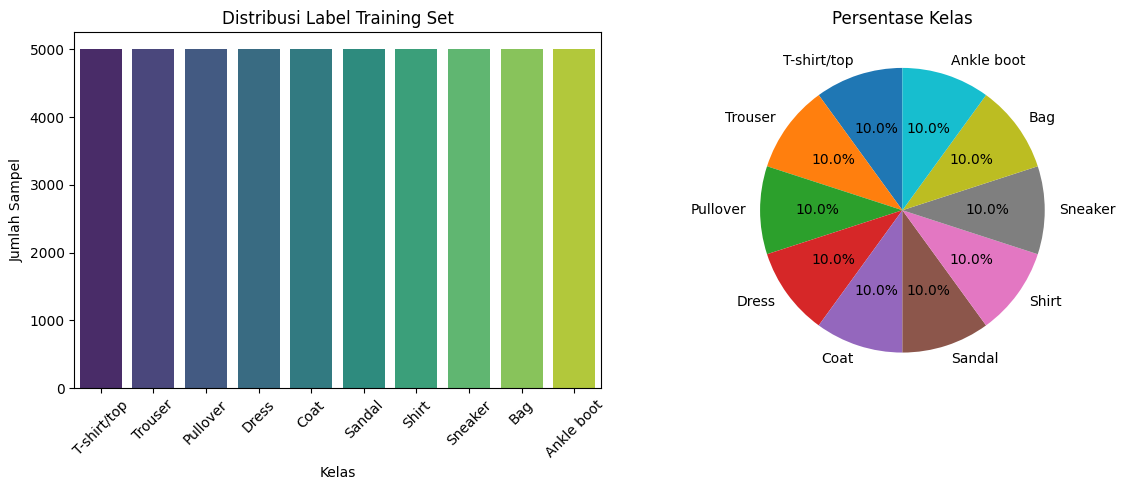

In [6]:
# Hitung frekuensi per kelas
class_counts = df['label'].value_counts().sort_index()
class_names = train_set.dataset.classes

# Tampilkan dalam DataFrame
label_dist = pd.DataFrame({
    'Kelas': class_names,
    'Jumlah': class_counts.values
})
print(label_dist)

# Visualisasi
plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
sns.barplot(x=class_names, y=class_counts.values, palette='viridis')
plt.title('Distribusi Label Training Set')
plt.ylabel('Jumlah Sampel')
plt.xlabel('Kelas')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.pie(class_counts.values, labels=class_names, autopct='%1.1f%%', startangle=90)
plt.title('Persentase Kelas')

plt.tight_layout()
plt.show()

## Statistik Dasar Dataset

In [7]:
print(f"jumlah training sample: {len(train_set)}")
print(f"jumlah test sample: {len(test_set)}")
print(f"dimensi gambar: {train_set[0][0].shape}")
print(f"jumlah kelas: {len(train_set.dataset.classes)}")

jumlah training sample: 50000
jumlah test sample: 10000
dimensi gambar: torch.Size([1, 28, 28])
jumlah kelas: 10


In [8]:
print(f"Rata-rata sampel per kelas: {class_counts.mean():.0f}")
print(f"Std dev sampel per kelas: {class_counts.std():.2f}")
print(f"Dataset seimbang? {'Ya' if class_counts.std() < 100 else 'Tidak sempurna'}")

Rata-rata sampel per kelas: 5000
Std dev sampel per kelas: 0.00
Dataset seimbang? Ya


## Visualiasi Gambar Dataset

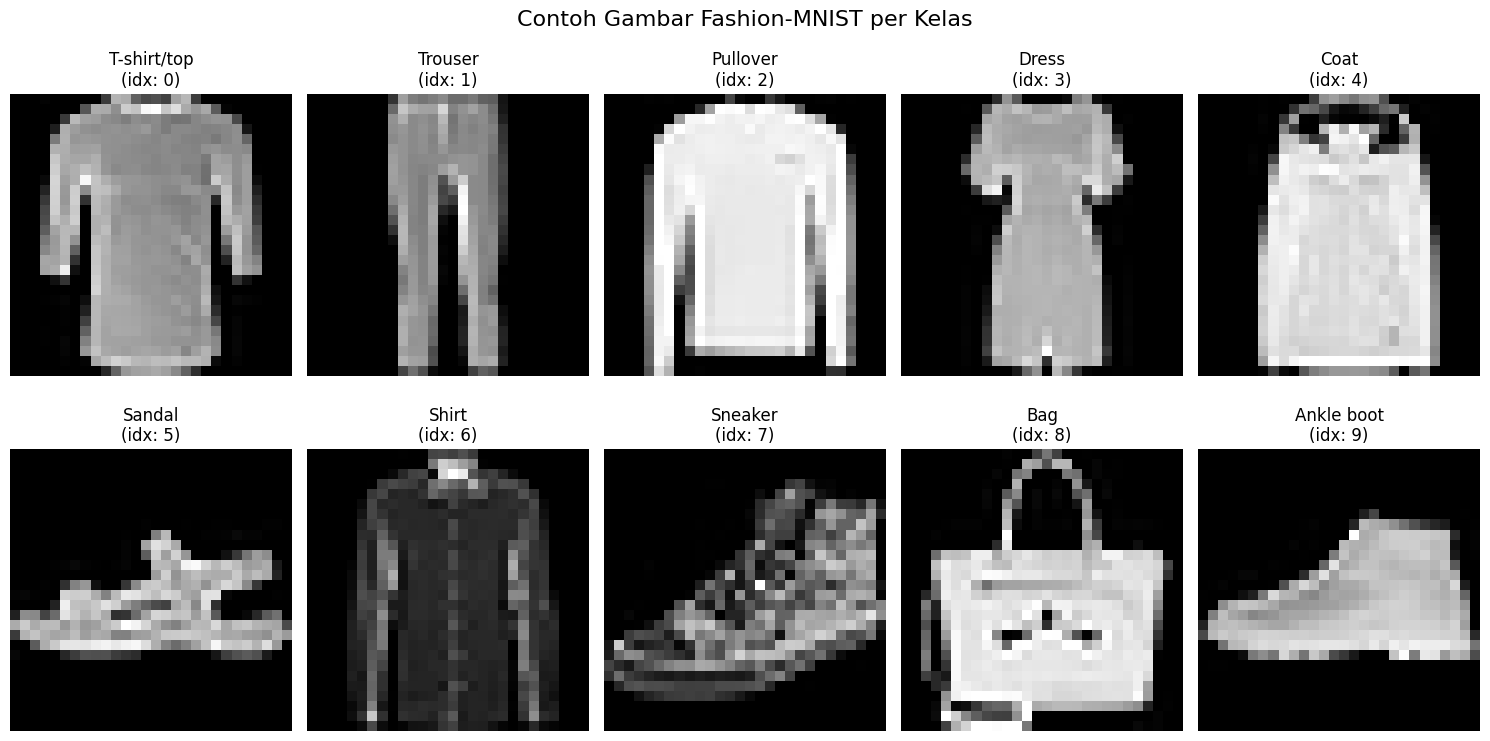

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
fig.suptitle('Contoh Gambar Fashion-MNIST per Kelas', fontsize=16)

for idx, class_name in enumerate(class_names):
    # Ambil satu gambar pertama dari setiap kelas
    class_indices = np.where(labels == idx)[0]
    sample_idx = class_indices[0]

    row = idx // 5
    col = idx % 5

    # Tampilkan gambar
    axes[row, col].imshow(images[sample_idx], cmap='gray')
    axes[row, col].set_title(f'{class_name}\n(idx: {idx})')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

## Brightness Distribution

      Kelas      Mean       Std  Min  Max
T-shirt/top 83.224407 89.566816    0  255
    Trouser 56.899187 87.625929    0  255
   Pullover 95.732759 91.250374    0  255
      Dress 65.980373 90.334488    0  255
       Coat 98.232895 95.971349    0  255
     Sandal 34.942414 67.169923    0  255
      Shirt 84.980171 86.840252    0  255
    Sneaker 42.777207 75.197685    0  255
        Bag 90.404486 93.196745    0  255
 Ankle boot 76.669061 94.392732    0  255


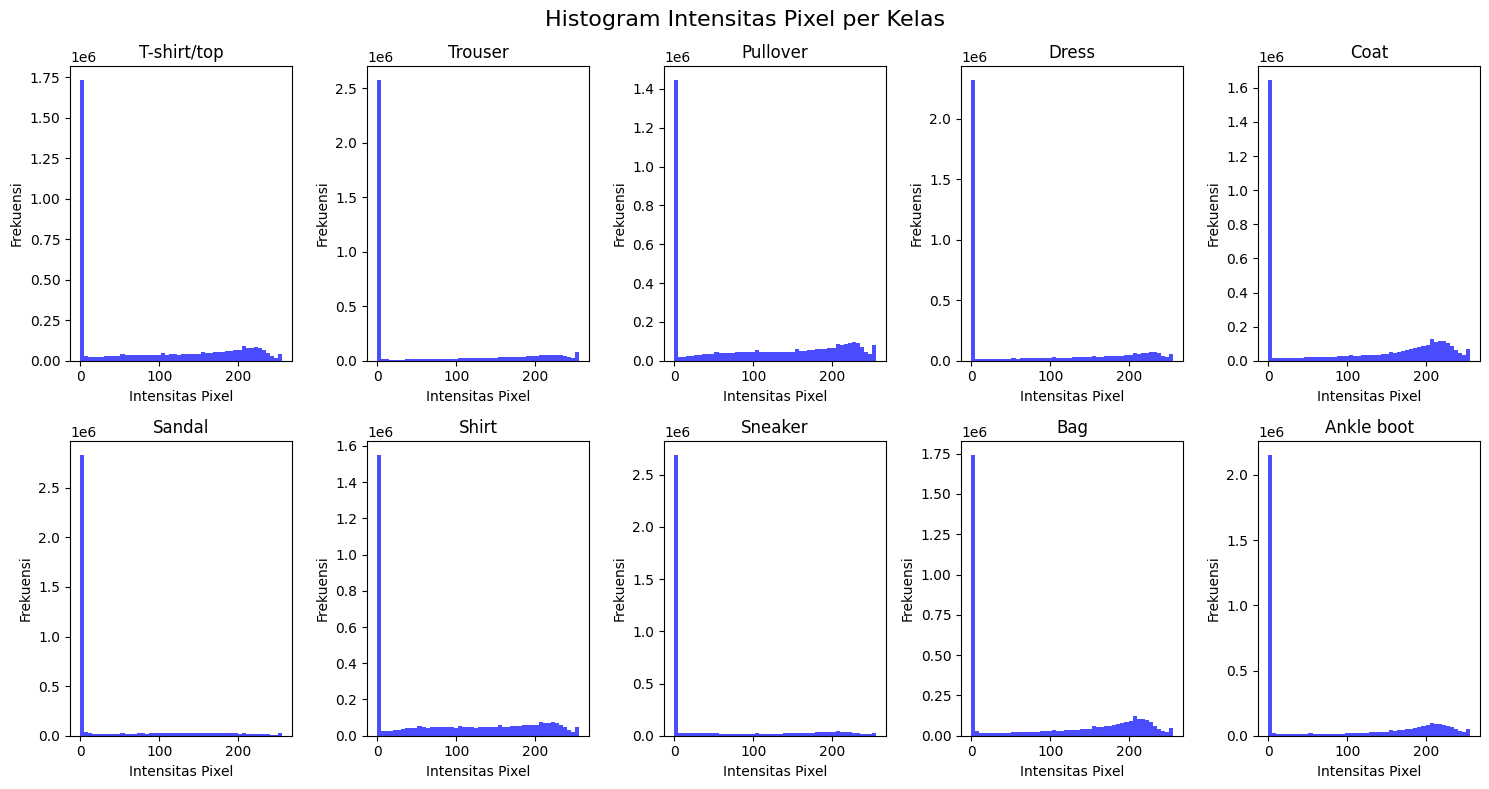

In [10]:
# Statistik ringkasan per kelas
pixel_stats = []
for i in range(10):
    class_images = images[labels == i]
    pixel_stats.append({
        'Kelas': class_names[i],
        'Mean': class_images.mean(),
        'Std': class_images.std(),
        'Min': class_images.min(),
        'Max': class_images.max()
    })

pixel_df = pd.DataFrame(pixel_stats)
print(pixel_df.to_string(index=False))

# Visualisasi distribusi pixel per kelas
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
fig.suptitle('Histogram Intensitas Pixel per Kelas', fontsize=16)

for idx, class_name in enumerate(class_names):
    row = idx // 5
    col = idx % 5

    class_images = images[labels == idx]
    axes[row, col].hist(class_images.flatten(), bins=50, alpha=0.7, color='blue')
    axes[row, col].set_title(f'{class_name}')
    axes[row, col].set_xlabel('Intensitas Pixel')
    axes[row, col].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

## Analisis Mean Intensitas Pixel

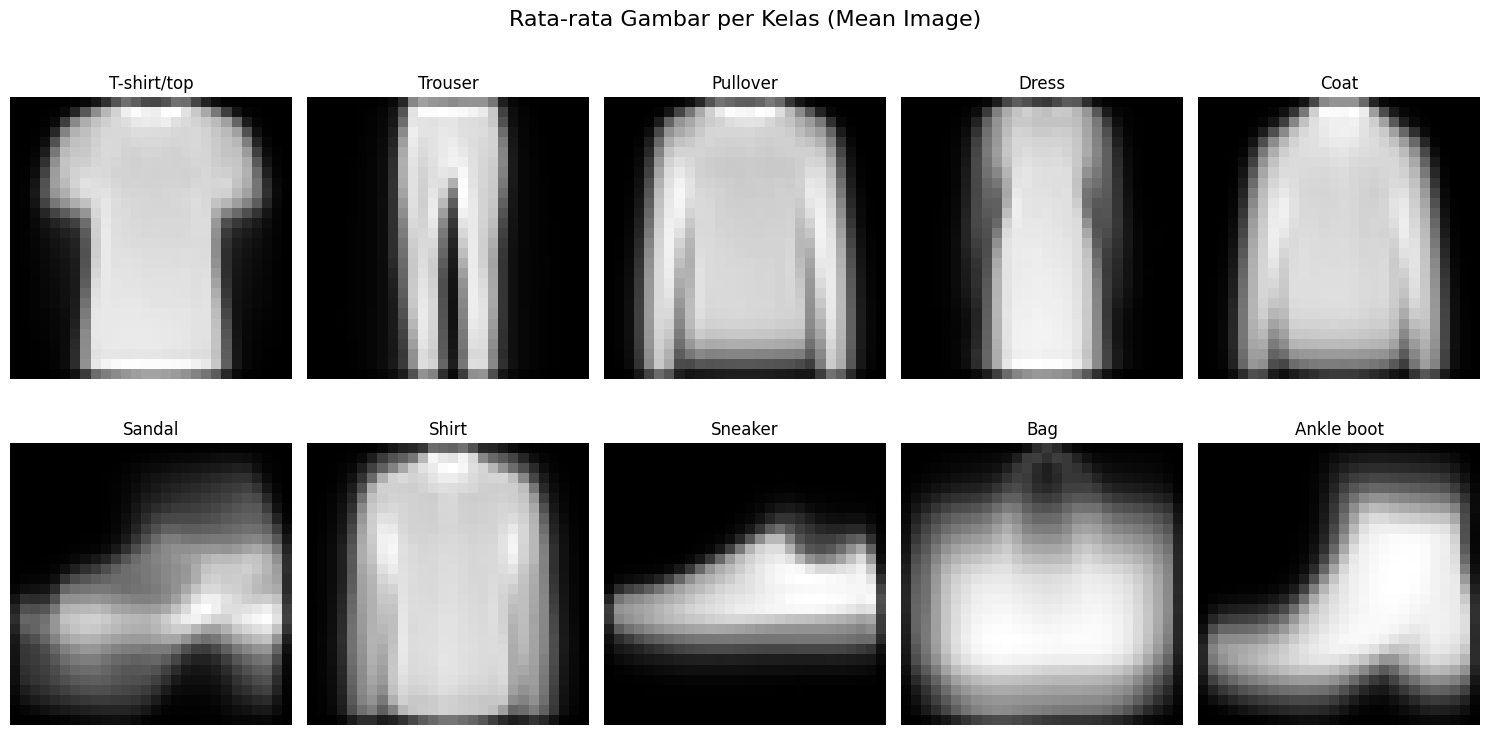


ANALISIS VARIANCE PIXEL
Variance global semua gambar: 0.1247
T-shirt/top    : 0.1234
Trouser        : 0.1181
Pullover       : 0.1281
Dress          : 0.1255
Coat           : 0.1416
Sandal         : 0.0694
Shirt          : 0.1160
Sneaker        : 0.0870
Bag            : 0.1336
Ankle boot     : 0.1370


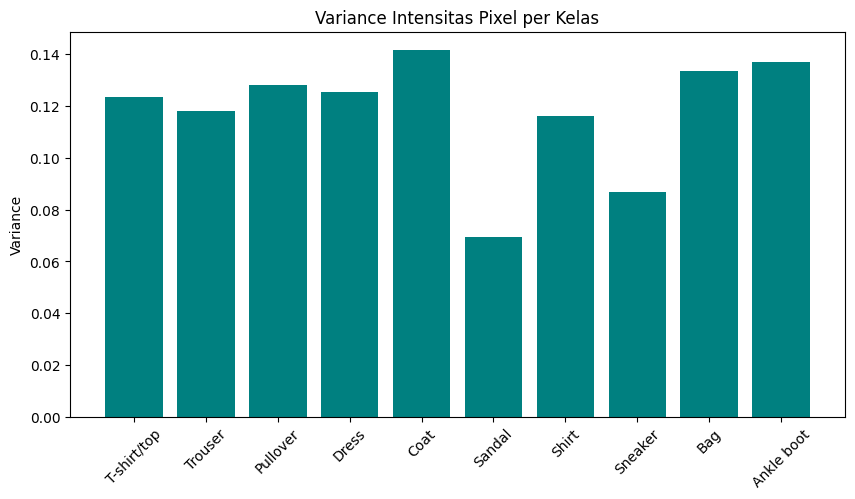

In [11]:
# Mean image per kelas
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
fig.suptitle('Rata-rata Gambar per Kelas (Mean Image)', fontsize=16)

for idx, class_name in enumerate(class_names):
    row = idx // 5
    col = idx % 5

    class_images = images[labels == idx]
    mean_img = class_images.mean(axis=0)

    axes[row, col].imshow(mean_img, cmap='gray')
    axes[row, col].set_title(f'{class_name}')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# Analisis variance per pixel (penting untuk normalisasi)
print("\n"+"ANALISIS VARIANCE PIXEL")
print("="*50)

# Hitung variance global
global_variance = np.var(images / 255.0)
print(f"Variance global semua gambar: {global_variance:.4f}")

# Variance per kelas
variance_per_class = []
for i in range(10):
    class_images = images[labels == i] / 255.0
    var = np.var(class_images)
    variance_per_class.append(var)
    print(f"{class_names[i]:15s}: {var:.4f}")

# Visualisasi variance per kelas
plt.figure(figsize=(10, 5))
plt.bar(class_names, variance_per_class, color='teal')
plt.title('Variance Intensitas Pixel per Kelas')
plt.ylabel('Variance')
plt.xticks(rotation=45)
plt.show()

# **DEFINISI FUNGSI MODULAR**

---



## Setup Fashion MNIST

In [12]:
def setup_fashion_mnist_environment(model_name, force_remount=True):
    """
    Menangani mounting drive, setup path, dan inisialisasi DataLoaders.
    """
    from google.colab import drive
    import os

    # 1. Mount Drive
    drive.mount('/content/drive', force_remount=True)

    # 2. Setup Paths
    model_dir = '/content/drive/MyDrive/model_modular'
    os.makedirs(model_dir, exist_ok=True)
    path = os.path.join(model_dir, model_name)


    train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=1000, shuffle=False)

    return path, train_loader, test_loader

print("✅ Helper function setup_fashion_mnist_environment siap digunakan.")

✅ Helper function setup_fashion_mnist_environment siap digunakan.


## Load or Training Model & Eval Model

In [13]:
import os
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

def evaluate_accuracy(model, data_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

def load_and_prepare_model(model_class, model_path, train_loader, test_loader, device, num_epochs=10, lr=0.001):
    model = model_class().to(device)
    history = {'loss': [], 'accuracy': []}

    if os.path.exists(model_path):
        print(f"✅ Loading existing model from {model_path}...")
        checkpoint = torch.load(model_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        history = checkpoint.get('history', history)
        print(f"✅ Model loaded. Previous accuracy: {history['accuracy'][-1]:.2f}%" if history['accuracy'] else "✅ Model loaded.")
    else:
        print(f"❌ No model found at {model_path}. Starting training...")
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)

        # 🔥 Track best model
        best_acc = 0.0
        best_model_state = None
        best_epoch = 0

        for epoch in range(num_epochs):
            model.train()
            running_loss = 0.0
            for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                running_loss += loss.item()

            acc = evaluate_accuracy(model, test_loader, device)
            avg_loss = running_loss / len(train_loader)
            history['loss'].append(avg_loss)
            history['accuracy'].append(acc)
            print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}, Accuracy = {acc:.2f}%")

            # 🔥 Simpan bobot jika akurasi terbaik
            if acc > best_acc:
                best_acc = acc
                best_epoch = epoch + 1
                best_model_state = copy.deepcopy(model.state_dict())
                print(f"   🏆 Best model updated (epoch {best_epoch}, acc {best_acc:.2f}%)")

        # 🔥 Load kembali bobot terbaik sebelum disimpan
        if best_model_state is not None:
            model.load_state_dict(best_model_state)
            print(f"\n✅ Restored best model from epoch {best_epoch} (acc {best_acc:.2f}%)")

        print(f"💾 Saving model to {model_path}...")
        torch.save({'model_state_dict': model.state_dict(), 'history': history}, model_path)
        print("✅ Training complete and model saved.")

    return model, history

print("✅ Unified Model Manager & Trainer defined!")

def get_best_accuracy(history, metric='accuracy'):

    if not history.get('accuracy'):
        print("⚠️ History kosong, tidak ada data akurasi.")
        return {
            'best_accuracy': 0.0,
            'best_epoch': 0,
            'best_loss': 0.0,
            'all_accuracies': [],
            'final_accuracy': 0.0
        }

    accuracies = history['accuracy']
    losses = history.get('loss', [])

    if metric == 'accuracy':
        best_value = max(accuracies)
        best_epoch = accuracies.index(best_value) + 1  # 1-indexed
    else:  # 'loss'
        best_value = min(losses) if losses else 0.0
        best_epoch = losses.index(best_value) + 1 if losses else 0

    result = {
        'best_accuracy': max(accuracies),
        'best_epoch': accuracies.index(max(accuracies)) + 1,
        'best_loss': min(losses) if losses else 0.0,
        'all_accuracies': accuracies,
        'final_accuracy': accuracies[-1]
    }

    print(f"📊 Best Accuracy : {result['best_accuracy']:.2f}% (Epoch {result['best_epoch']})")
    print(f"📊 Final Accuracy: {result['final_accuracy']:.2f}% (Epoch {len(accuracies)})")
    print(f"📊 Best Loss     : {result['best_loss']:.4f}")

    return result

✅ Unified Model Manager & Trainer defined!


## Fungsi Kuantisasi Modular

Standard & Fine-Grained Quantization Ternary


In [14]:
import torch
import torch.nn as nn
import copy
import numpy as np
import os
import json

def standard_ternary_quantize(weight_tensor, asymmetric=False):
    """
    Standard ternary quantization dengan alpha yang akurat.
    """
    original_shape = weight_tensor.shape
    flat_weights = weight_tensor.flatten()

    if not asymmetric:
        abs_weights = torch.abs(flat_weights)
        if abs_weights.max().item() == 0:
            return torch.zeros_like(weight_tensor), 0.0

        # 🔥 Hitung threshold
        delta = 0.5 * torch.mean(abs_weights)
        mask = abs_weights > delta

        if mask.sum() == 0:
            return torch.zeros_like(weight_tensor), 0.0

        # 🔥 Buat bobot ternary
        ternary_flat = torch.zeros_like(flat_weights)
        ternary_flat[flat_weights > delta] = 1.0   # sementara +1
        ternary_flat[flat_weights < -delta] = -1.0 # sementara -1

        # 🔥 Hitung alpha dari bobot yang sudah ternarized
        # Ambil nilai absolut dari bobot yang bukan nol
        nonzero_mask = ternary_flat != 0
        if nonzero_mask.sum() > 0:
            # Alpha adalah rata-rata dari |bobot asli| yang lolos threshold
            alpha = abs_weights[mask].mean()
        else:
            alpha = 0.0

        # 🔥 Terapkan alpha
        ternary_flat *= alpha

        # 🔥 VERIFIKASI: Pastikan alpha yang dikembalikan sama dengan yang digunakan
        return ternary_flat.reshape(original_shape), alpha.item()
    else:
        # Asymmetric version
        pos_mask = flat_weights > 0
        neg_mask = flat_weights < 0
        a_pos, a_neg = 0.0, 0.0
        d_pos, d_neg = 0.0, 0.0

        if pos_mask.any():
            pos_vals = flat_weights[pos_mask]
            d_pos = 0.7 * torch.mean(pos_vals)
            m_pos = pos_vals > d_pos
            if m_pos.any():
                a_pos = pos_vals[m_pos].mean()

        if neg_mask.any():
            neg_vals = flat_weights[neg_mask]
            d_neg = 0.7 * torch.mean(torch.abs(neg_vals))
            m_neg = torch.abs(neg_vals) > d_neg
            if m_neg.any():
                a_neg = neg_vals[m_neg].mean()

        ternary_flat = torch.zeros_like(flat_weights)
        ternary_flat[flat_weights > d_pos] = a_pos
        ternary_flat[flat_weights < -d_neg] = a_neg

        avg_alpha = (abs(a_pos) + abs(a_neg)) / 2.0
        return ternary_flat.reshape(original_shape), avg_alpha.item()

def apply_standard_ternary_to_model(model, asymmetric=False, verbose=False,
                                   save_path=None, skip_conv1=False):
    """
    Apply standard ternary quantization to model.
    """
    if save_path and os.path.exists(save_path):
        print(f"✅ Loading existing Standard Ternary model from {save_path}...")
        return load_ternary_safetensors(save_path, model), None

    model_q = copy.deepcopy(model)
    layer_alphas = []

    # 🔥 Deteksi ResNet
    is_resnet = hasattr(model_q, 'model') and hasattr(model_q.model, 'conv1')

    for name, module in model_q.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            # 🔥 HANYA skip conv1, BUKAN semua layer!
            should_skip = False
            if skip_conv1:
                # Hanya skip jika nama layer adalah 'model.conv1' atau 'conv1'
                if name == 'model.conv1' or name == 'conv1':
                    should_skip = True

            if should_skip:
                if verbose:
                    print(f"  ⏭️ {name}: skipped (kept FP32)")
                continue

            # 🔥 Kuantisasi layer lainnya
            ternary_weight, alpha = standard_ternary_quantize(
                module.weight.data,
                asymmetric=asymmetric
            )
            module.weight.data = ternary_weight

            # 🔥 Gunakan alpha dari bobot AKTUAL
            actual_alpha = get_alpha_from_weight(module.weight.data)
            layer_alphas.append(actual_alpha)

            if verbose:
                print(f"  ✓ {name}: quantized with alpha={actual_alpha:.4f}")

    if save_path:
        save_ternary_safetensors(model_q, alphas=layer_alphas, path=save_path)
    return model_q, layer_alphas

def get_alpha_from_weight(weight_tensor):
    """
    Ekstrak alpha dari bobot ternary yang sudah jadi.
    Alpha adalah nilai absolut terbesar dari bobot non-zero.
    """
    w = weight_tensor.flatten()
    # Ambil nilai unik (dengan toleransi pembulatan)
    unique_vals = torch.unique(w.round(decimals=6))
    # Ambil nilai positif (alpha)
    pos_vals = unique_vals[unique_vals > 0]
    if len(pos_vals) > 0:
        return pos_vals.max().item()
    return 0.0

def ternary_quantize_group(weight_tensor, group_size=4, asymmetric=False):
    original_shape = weight_tensor.shape
    flat_weights = weight_tensor.flatten()
    n = flat_weights.numel()
    ternary_flat = torch.zeros_like(flat_weights)
    alphas = []
    for i in range(0, n, group_size):
        group = flat_weights[i:min(i+group_size, n)]
        if len(group) == 0: continue
        if not asymmetric:
            abs_group = torch.abs(group)
            if abs_group.max().item() == 0:
                alphas.append(0.0)
                continue
            thresholds = torch.linspace(abs_group.min().item(), abs_group.max().item(), steps=20)
            best_delta, best_score = 0, -float('inf')
            for delta in thresholds:
                mask = abs_group > delta
                if mask.sum() == 0: continue
                score = (abs_group[mask].sum() ** 2) / mask.sum().float()
                if score > best_score: best_score, best_delta = score, delta
            mask = abs_group > best_delta
            if mask.sum() == 0:
                alphas.append(0.0)
                continue
            alpha = abs_group[mask].sum() / mask.sum().float()
            alphas.append(alpha.item())
            ternary_group = torch.zeros_like(group)
            ternary_group[group > best_delta] = alpha
            ternary_group[group < -best_delta] = -alpha
        else:
            pos_mask = group > 0
            neg_mask = group < 0
            a_pos, a_neg = 0.0, 0.0
            d_pos, d_neg = 0.0, 0.0
            if pos_mask.any():
                pos_vals = group[pos_mask]
                d_pos = 0.7 * torch.mean(pos_vals)
                m_pos = pos_vals > d_pos
                if m_pos.any(): a_pos = torch.mean(pos_vals[m_pos])
            if neg_mask.any():
                neg_vals = group[neg_mask]
                d_neg = 0.7 * torch.mean(torch.abs(neg_vals))
                m_neg = torch.abs(neg_vals) > d_neg
                if m_neg.any(): a_neg = torch.mean(neg_vals[m_neg])
            ternary_group = torch.zeros_like(group)
            ternary_group[group > d_pos] = a_pos
            ternary_group[group < -d_neg] = a_neg
            alphas.append((abs(a_pos) + abs(a_neg)).item() / 2.0 if torch.is_tensor(a_pos) else (abs(a_pos) + abs(a_neg)) / 2.0)
        ternary_flat[i:min(i+group_size, n)] = ternary_group
    return ternary_flat.reshape(original_shape), alphas

def apply_fgq_to_model(model, group_size=4, asymmetric=False, verbose=False, save_path=None):
    if isinstance(group_size, (list, set, tuple)):
        results = {}
        for gs in sorted(list(group_size)):
            sub_save_path = save_path.replace('.safetensors', f'_gs{gs}.safetensors') if save_path else None
            if sub_save_path and os.path.exists(sub_save_path):
                if verbose: print(f"✅ Loading existing FGQ model (GS={gs}) from {sub_save_path}...")
                m_q = load_ternary_safetensors(sub_save_path, model)
                results[gs] = (m_q, None)
            else:
                if verbose: print(f"\n--- Processing Group Size: {gs} (Asymmetric={asymmetric}) ---")
                m_q, a_m = apply_fgq_to_model(model, gs, asymmetric, verbose, sub_save_path)
                results[gs] = (m_q, a_m)
        return results

    if save_path and os.path.exists(save_path):
        print(f"✅ Loading existing FGQ model (GS={group_size}) from {save_path}...")
        return load_ternary_safetensors(save_path, model), None

    model_q = copy.deepcopy(model)
    all_alpha_means = []
    for name, module in model_q.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            ternary_weight, alphas = ternary_quantize_group(module.weight.data, group_size, asymmetric)
            module.weight.data = ternary_weight
            m_alpha = np.mean(alphas) if alphas else 0
            all_alpha_means.append(m_alpha)
            if verbose: print(f"  ✓ {name}: FGQ N={group_size}, Asym={asymmetric}, mean_alpha={m_alpha:.4f}")

    if save_path:
        save_ternary_safetensors(model_q, group_size=group_size, path=save_path)
    return model_q, all_alpha_means

def find_best_fgq_model(fgq_results, test_loader, device, save_log_path=None):
    best_acc = -1.0
    best_gs = None
    best_model = None
    accuracy_log = {}

    print("\n--- Evaluating All Group Sizes ---")
    for gs, (model_q, _) in fgq_results.items():
        acc = evaluate_accuracy(model_q, test_loader, device)
        accuracy_log[int(gs)] = float(acc)
        print(f"Group Size {gs}: Accuracy = {acc:.2f}%")
        if acc > best_acc:
            best_acc = acc
            best_gs = gs
            best_model = model_q

    print(f"\n✅ Best Result: Group Size {best_gs} with Accuracy {best_acc:.2f}%")

    if save_log_path:
        with open(save_log_path, 'w') as f:
            json.dump({"model_info": "FGQ Results", "accuracies": accuracy_log, "best_gs": int(best_gs)}, f, indent=4)
        print(f"💾 Accuracy log saved to: {save_log_path}")

    return best_gs, best_model, best_acc

## Definisi Model

### LeNet-5

In [15]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Redefine Model Class
class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = nn.functional.avg_pool2d(x, 2)
        x = torch.relu(self.conv2(x))
        x = nn.functional.avg_pool2d(x, 2)
        x = x.view(-1, 16 * 5 * 5)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# 2. Re-initialize DataLoader
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
test_dataset = datasets.FashionMNIST(root='./data_fashion', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# 3. Instantiate model and define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LeNet5().to(device)

print("✅ Setup for verification complete: Model and Test Loader are ready.")

✅ Setup for verification complete: Model and Test Loader are ready.


### ResNet-18

In [16]:
import torch
import torch.nn as nn
from torchvision import models

# 1. Redefine Model Class for ResNet18
class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNet18, self).__init__()
        # Load a pre-trained ResNet18 model
        self.model = models.resnet18(weights=None) # weights=None to avoid downloading ImageNet weights for now

        # Modify the first convolution layer for single-channel input (Fashion MNIST images are grayscale)
        self.model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        # Modify the final fully connected layer to match the number of classes (Fashion MNIST has 10 classes)
        num_ftrs = self.model.fc.in_features
        self.model.fc = nn.Linear(num_ftrs, num_classes)

    def forward(self, x):
        return self.model(x)

# Instantiate model and define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ResNet18().to(device)

print("✅ ResNet18 model defined and ready.")

✅ ResNet18 model defined and ready.


#### Modification

In [17]:
import torch
import torch.nn as nn
from torchvision import models

# 1. Redefine Model Class for ResNet18
class ResNet18Modified(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNet18Modified, self).__init__()
        # Load a pre-trained ResNet18 model
        self.model = models.resnet18(weights=None) # weights=None to avoid downloading ImageNet weights for now

        # Modify the first convolution layer for single-channel input (Fashion MNIST images are grayscale)
        self.model.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
        model.maxpool = nn.Identity()

        # Modify the final fully connected layer to match the number of classes (Fashion MNIST has 10 classes)
        num_ftrs = self.model.fc.in_features
        self.model.fc = nn.Linear(num_ftrs, num_classes)

    def forward(self, x):
        return self.model(x)

# Instantiate model and define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ResNet18Modified().to(device)

print("✅ ResNet18 Modified model defined and ready.")

✅ ResNet18 Modified model defined and ready.


## Fungsi Penyimpanan Kuantisasi

In [18]:
import torch
import os
import copy
import json
from safetensors.torch import save_file, load_file
from safetensors import safe_open

def pack_2bit(mask):
    """
    Pack 4 ternary values into 1 byte (using 0, 1, 2 mapping)
    """
    if mask.device.type == 'cuda':
        mask = mask.cpu()

    # 🔥 Pastikan mask hanya berisi 0, 1, 2
    mask = mask.clamp(0, 2)

    flat = mask.flatten().to(torch.uint8)
    n = flat.numel()
    pad = (4 - (n % 4)) % 4
    if pad > 0:
        flat = torch.cat([flat, torch.zeros(pad, dtype=torch.uint8)])

    # Reshape ke (N/4, 4)
    grouped = flat.view(-1, 4)

    # 🔥 Pack dengan bit operation yang aman
    packed = torch.zeros(grouped.size(0), dtype=torch.uint8)
    for i in range(4):
        # Pastikan nilai 0-3, lalu shift
        packed |= (grouped[:, i] & 3) << (2 * i)

    return packed, mask.shape

def unpack_2bit(packed, shape, numel):
    """
    Unpack uint8 back to ternary mask
    """
    if packed.device.type == 'cuda':
        packed = packed.cpu()

    n = packed.numel()
    # Unpack: 1 byte menjadi 4 nilai 2-bit
    unpacked = torch.zeros(n, 4, dtype=torch.uint8)
    for i in range(4):
        unpacked[:, i] = (packed >> (2 * i)) & 3

    # 🔥 Flatten dan ambil sesuai numel
    mask = unpacked.flatten()[:numel].reshape(shape)
    return mask.to(torch.int8)

def get_alpha_from_weight(weight_tensor):
    """
    [Dipertahankan untuk kompatibilitas / debugging]
    Ekstrak SATU alpha global dari bobot ternary (nilai absolut terbesar).
    ⚠️ JANGAN dipakai untuk save/load FGQ atau asymmetric — gunakan
    get_group_alphas_from_weight, karena satu layer bisa punya banyak alpha berbeda.
    """
    w = weight_tensor.flatten()
    unique_vals = torch.unique(w.round(decimals=6))
    pos_vals = unique_vals[unique_vals > 0]
    if len(pos_vals) > 0:
        return pos_vals.max().item()
    return 0.0

# ============================================================
# 🔧 FIX: ekstraksi alpha PER GRUP (bukan satu alpha global per layer)
# ============================================================
def get_group_alphas_from_weight(w_flat, group_size):
    """
    Untuk tiap grup sepanjang `group_size` elemen (berurutan sesuai flatten),
    ekstrak alpha positif & alpha negatif dari bobot yang SUDAH dikuantisasi.

    - Bekerja untuk symmetric (alpha_pos == alpha_neg per grup) maupun
      asymmetric (alpha_pos != alpha_neg per grup) secara otomatis, karena
      nilainya diambil langsung dari bobot ternary hasil kuantisasi.
    - Bekerja juga untuk "standard ternary" (bukan FGQ) dengan cara
      memanggil fungsi ini dengan group_size = numel (artinya: 1 grup
      mencakup seluruh layer) — jadi satu fungsi ini menggantikan
      get_alpha_from_weight() di semua kasus save/load.

    Return: (alpha_pos, alpha_neg) — masing-masing tensor 1D sepanjang
    jumlah grup (n_groups).
    """
    n = w_flat.numel()
    n_groups = (n + group_size - 1) // group_size
    alpha_pos = torch.zeros(n_groups, dtype=torch.float32)
    alpha_neg = torch.zeros(n_groups, dtype=torch.float32)
    for gi in range(n_groups):
        start = gi * group_size
        end = min(start + group_size, n)
        chunk = w_flat[start:end]
        pos = chunk[chunk > 0]
        neg = chunk[chunk < 0]
        if pos.numel() > 0:
            alpha_pos[gi] = pos.max()
        if neg.numel() > 0:
            alpha_neg[gi] = neg.abs().max()
    return alpha_pos, alpha_neg


def save_ternary_safetensors(model, alphas=None, group_size=None, path='model.safetensors',
                            skip_layers=None):
    """
    alphas   : sudah tidak dipakai untuk perhitungan (dipertahankan hanya demi
               kompatibilitas signature dengan kode lama) — alpha SELALU
               diekstrak ulang langsung dari bobot ter-kuantisasi, PER GRUP.
    group_size: ukuran grup FGQ (4/8/16, dst). None berarti "standard ternary"
               → 1 grup mencakup seluruh layer (perilaku lama, tapi kini benar
               untuk asymmetric juga karena alpha_pos & alpha_neg disimpan
               terpisah, bukan digabung/di-max-kan).
    """
    if skip_layers is None:
        skip_layers = []

    model = model.cpu()
    tensors = {}
    meta_list = []
    total_layers = 0
    saved_layers = 0

    print("\n📝 Proses Save Model ke Safetensors (FIXED: per-group alpha)")
    print("="*60)

    for name, module in model.named_modules():
        if name in skip_layers:
            print(f"  ⏭️ SKIP (FP32): {name}")
            continue

        # --- BatchNorm ---
        if isinstance(module, (nn.BatchNorm2d, nn.BatchNorm1d)):
            total_layers += 1
            tensors[f"{name}.weight"] = module.weight.data.clone()
            tensors[f"{name}.bias"] = module.bias.data.clone()
            tensors[f"{name}.running_mean"] = module.running_mean.clone()
            tensors[f"{name}.running_var"] = module.running_var.clone()
            meta_list.append({"n": name, "type": "bn"})
            saved_layers += 1
            print(f"  ✅ BN: {name}")
            continue

        # --- Conv2d / Linear ---
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            total_layers += 1
            w = module.weight.data
            w_flat = w.flatten()
            gs = group_size if group_size else w_flat.numel()  # standard ternary -> 1 grup (whole layer)

            print(f"  🔄 Processing: {name}")
            print(f"     - Shape: {w.shape}  | group_size dipakai: {gs}")

            # 🔥 FIX: alpha per grup (pos & neg terpisah), bukan satu alpha global
            alpha_pos, alpha_neg = get_group_alphas_from_weight(w_flat, gs)
            tensors[f"{name}.alpha_pos"] = alpha_pos.to(torch.float16)
            tensors[f"{name}.alpha_neg"] = alpha_neg.to(torch.float16)
            print(f"     - Jumlah grup alpha: {len(alpha_pos)} "
                  f"(distinct pos={len(torch.unique(alpha_pos[alpha_pos>0]))}, "
                  f"distinct neg={len(torch.unique(alpha_neg[alpha_neg>0]))})")

            # Buat mask ternary untuk packing
            m = torch.zeros_like(w, dtype=torch.int8)
            m[w < 0] = 0
            m[w == 0] = 1
            m[w > 0] = 2

            packed, original_shape = pack_2bit(m)
            tensors[f"{name}.p"] = packed

            info = {
                "n": name,
                "type": "linear",
                "s": list(original_shape),
                "num": w.numel(),
                "group_size": gs,
                "has_bias": module.bias is not None,
            }

            if module.bias is not None:
                tensors[f"{name}.bias"] = module.bias.data.clone()

            meta_list.append(info)
            saved_layers += 1
            print(f"     ✅ Saved to metadata")

    print("="*60)
    print(f"📊 Total layer ditemukan: {total_layers}")
    print(f"📊 Layer disimpan: {saved_layers}")
    print(f"📊 Layer di-skip: {len(skip_layers)}")

    if saved_layers == 0:
        print("❌ ERROR: Tidak ada layer yang disimpan!")
        return meta_list

    save_file(tensors, path, metadata={"config": json.dumps(meta_list)})

    file_size = os.path.getsize(path) / 1024
    print(f"✅ Saved: {path} ({file_size:.1f} KB, {len(meta_list)} layers)")

    return meta_list

def load_ternary_safetensors(path, template_model, verbose=True):
    from safetensors import safe_open

    tensors = load_file(path)

    if verbose:
        print("\n🔍 Debug Load (FIXED: per-group alpha):")
        print("="*60)

    with safe_open(path, framework="pt") as f:
        metadata = f.metadata()
        config_str = metadata["config"]
        meta_list = json.loads(config_str)
        if verbose:
            print(f"✅ Berhasil parse JSON: {len(meta_list)} layers")

    model = copy.deepcopy(template_model)
    state_dict = model.state_dict()
    loaded_keys = set()

    for info in meta_list:
        name = info["n"]

        if info.get("type") == "bn":
            for suffix in ['.weight', '.bias', '.running_mean', '.running_var']:
                key = f"{name}{suffix}"
                if key in state_dict:
                    state_dict[key] = tensors[f"{name}{suffix}"]
                    loaded_keys.add(key)
            continue

        if info.get("type") == "linear":
            weight_key = f"{name}.weight"

            packed = tensors[f"{name}.p"]
            mask = unpack_2bit(packed, info["s"], info["num"])
            mask_flat = mask.flatten()

            n = info["num"]
            gs = info.get("group_size", n)  # fallback: file lama = 1 grup (whole layer)

            if f"{name}.alpha_pos" in tensors and f"{name}.alpha_neg" in tensors:
                # 🔥 FIX: broadcast alpha PER GRUP ke tiap elemen sesuai grupnya
                alpha_pos = tensors[f"{name}.alpha_pos"]
                alpha_neg = tensors[f"{name}.alpha_neg"]
                n_groups = alpha_pos.numel()
                group_idx = (torch.arange(n) // gs).clamp(max=n_groups - 1)
                ap = alpha_pos[group_idx]
                an = alpha_neg[group_idx]

                w_rec = torch.zeros(n, dtype=torch.float16)
                w_rec[mask_flat == 2] = ap[mask_flat == 2]
                w_rec[mask_flat == 0] = -an[mask_flat == 0]

                if verbose:
                    print(f"  📊 {name}: {n_groups} grup alpha (group_size={gs}) berhasil di-broadcast")
            elif f"{name}.alpha" in tensors:
                # Kompatibilitas mundur: file lama format single-alpha (buggy)
                alpha = tensors[f"{name}.alpha"].item()
                w_rec = torch.zeros(n, dtype=torch.float16)
                w_rec[mask_flat == 2] = alpha
                w_rec[mask_flat == 0] = -alpha
                if verbose:
                    print(f"  ⚠️ {name}: file lama (format single-alpha), akurasi mungkin masih mismatch")
            else:
                w_rec = torch.zeros(n, dtype=torch.float16)

            # Verifikasi perbedaan
            if verbose and weight_key in state_dict:
                orig_w = state_dict[weight_key].flatten().cpu()
                rec_w = w_rec.flatten().cpu()
                max_diff = (orig_w - rec_w).abs().max().item()
                if max_diff > 1e-2:
                    print(f"     ⚠️ PERBEDAAN DETEKSI! max_diff={max_diff:.6f}")
                    print(f"        Orig mean: {orig_w.mean().item():.6f}, Rec mean: {rec_w.mean().item():.6f}")
                else:
                    print(f"     ✅ Cocok (max_diff={max_diff:.6f})")

            state_dict[weight_key] = w_rec.reshape(info["s"])
            loaded_keys.add(weight_key)

            if info.get("has_bias", False) and f"{name}.bias" in tensors:
                state_dict[f"{name}.bias"] = tensors[f"{name}.bias"]
                loaded_keys.add(f"{name}.bias")

    model.load_state_dict(state_dict)
    return model


## Generate Input Batch

In [19]:
import torch
import numpy as np
from torchvision import datasets, transforms

# Load Fashion-MNIST test set
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Ambil 100 gambar pertama
batch_size = 100
inputs = []
for i in range(batch_size):
    img, label = test_dataset[i]
    input_flat = img.numpy().flatten().astype(np.float32)
    inputs.append(input_flat)

# Simpan sebagai satu file .bin (100 x 784 = 78,400 float32)
all_inputs = np.array(inputs).flatten()
all_inputs.tofile('batch_input.bin')
print(f"✅ Batch input saved: {all_inputs.shape}")

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.63MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.71MB/s]

✅ Batch input saved: (78400,)


# **PENGUJIAN TRAINING & KUANTISASI**

---



## Model Setup

#### ResNet-18

In [22]:
# 1. Siapkan environment (Drive, Path, Data)
model_path_resnet, train_loader_resnet, test_loader_resnet = setup_fashion_mnist_environment('resnet18_fashion_baseline_v8_modified_stratified.pth')
# model_path_resnet, train_loader_resnet, test_loader_resnet = setup_fashion_mnist_environment('resnet18_fashion_baseline_v2.pth')

# 2. Panggil manager model
model_fp32_resnet, history_resnet = load_and_prepare_model(
    ResNet18Modified,
    model_path_resnet,
    train_loader_resnet,
    test_loader_resnet,
    device,
    num_epochs=50,
    lr=0.0002
)

best_info_resnet = get_best_accuracy(history_resnet)
print(f"Baseline terbaik: {best_info_resnet['best_accuracy']:.2f}% (epoch {best_info_resnet['best_epoch']})")

Mounted at /content/drive
✅ Loading existing model from /content/drive/MyDrive/model_modular/resnet18_fashion_baseline_v8_modified_stratified.pth...
✅ Model loaded. Previous accuracy: 92.18%
📊 Best Accuracy : 92.64% (Epoch 22)
📊 Final Accuracy: 92.18% (Epoch 30)
📊 Best Loss     : 0.0102
Baseline terbaik: 92.64% (epoch 22)


##### Modified

In [ ]:
# 1. Siapkan environment (Drive, Path, Data)
model_path_resnet_modified, train_loader_resnet_modified, test_loader_resnet_modified = setup_fashion_mnist_environment('resnet18_fashion_baseline_v3_modified_stratified.pth')

# 2. Panggil manager model
model_fp32_resnet_modified, history_resnet_modified = load_and_prepare_model(
    ResNet18Modified,
    model_path_resnet_modified,
    train_loader_resnet_modified,
    test_loader_resnet_modified,
    device,
    num_epochs=30,
    lr=0.002
)

best_info_resnet_modified = get_best_accuracy(history_resnet_modified)
print(f"Baseline terbaik: {best_info_resnet_modified['best_accuracy']:.2f}% (epoch {best_info_resnet_modified['best_epoch']})")

#### LeNet-5

In [ ]:
# 1. Siapkan environment (Drive, Path, Data)
model_path_lenet, train_loader_lenet, test_loader_lenet = setup_fashion_mnist_environment('lenet5_fashion_baseline_v5_stratified.pth')
# model_path_lenet, train_loader_lenet, test_loader_lenet = setup_fashion_mnist_environment('lenet5_fashion_baseline_v2.pth')

# 2. Panggil manager model
model_fp32_lenet, history_lenet = load_and_prepare_model(
    LeNet5,
    model_path_lenet,
    train_loader_lenet,
    test_loader_lenet,
    device,
    num_epochs=50,
    lr=0.005
)

best_info_lenet = get_best_accuracy(history_lenet)
print(f"Baseline terbaik: {best_info_lenet['best_accuracy']:.2f}% (epoch {best_info_lenet['best_epoch']})")

## Kuantisasi Model

### *Standard Ternary Quantization*

In [ ]:
# Simpan bobot conv1 FP32 (opsional, untuk backup)
conv1_original = model_fp32_resnet.model.conv1.weight.data.clone()

#### ResNet-18

Asymmetric

Sebelum disimpan :
- Baseline: 91.11%
- Ternary: 58.46%

Sesudah disimpan :
- Ternary: 23.04%

Tanpa skip

Sebelum disimpan :
- Ternary : 42.19%

Sesudah disimpan :
- Ternary : 42.19%

##### Symmetric threshold

In [23]:
model_ternary_resnet, alphas_resnet = apply_standard_ternary_to_model(model_fp32_resnet, asymmetric=False, verbose=True, skip_conv1=False, save_path="/content/drive/MyDrive/model_modular/safetensors_models/resnet18_standard_fashion_v8_modified_stratified_symmetric.safetensors")
acc_ternary_resnet = evaluate_accuracy(model_ternary_resnet, test_loader, device)

print(f"Baseline: {best_info_resnet['best_accuracy']:.2f}%")
print(f"Ternary: {acc_ternary_resnet:.2f}%")

✅ Loading existing Standard Ternary model from /content/drive/MyDrive/model_modular/safetensors_models/resnet18_standard_fashion_v8_modified_stratified_symmetric.safetensors...

🔍 Debug Load (FIXED: per-group alpha):
✅ Berhasil parse JSON: 41 layers
  📊 model.conv1: 1 grup alpha (group_size=576) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=1.040718
        Orig mean: -0.031455, Rec mean: -0.020630
  📊 model.layer1.0.conv1: 1 grup alpha (group_size=36864) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=2.866944
        Orig mean: -0.010076, Rec mean: -0.007088
  📊 model.layer1.0.conv2: 1 grup alpha (group_size=36864) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=1.355095
        Orig mean: -0.055331, Rec mean: -0.043549
  📊 model.layer1.1.conv1: 1 grup alpha (group_size=36864) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=1.472235
        Orig mean: -0.025758, Rec mean: -0.020447
  📊 model.layer1.1.conv2: 1 grup alpha (group_size=36864) ber

In [ ]:
import os

# Tentukan path lengkap ke file di Google Drive
save_dir = '/content/drive/MyDrive/model_modular/safetensors_models'
model_filename = 'resnet18_standard_fashion_v5_next_stratified_symmetric.safetensors'
model_path = os.path.join(save_dir, model_filename)

# Load model menggunakan template ResNet18
if os.path.exists(model_path):
    model_loaded = load_ternary_safetensors(model_path, ResNet18())
    model_loaded.to(device)

    # Evaluasi sebelum dan sesudah
    model_ternary_resnet.eval()
    acc_before = evaluate_accuracy(model_ternary_resnet, test_loader, device)

    model_loaded.eval()
    acc_after = evaluate_accuracy(model_loaded, test_loader, device)

    print(f"Akurasi sebelum save: {acc_before:.2f}%")
    print(f"Akurasi setelah load: {acc_after:.2f}%")
    print(f"✅ Sama? {'Ya' if abs(acc_before - acc_after) < 0.01 else 'Tidak'}")

    # Verifikasi bobot conv1 tetap FP32
    if hasattr(model_loaded, 'model'):
        print(f"Conv1 mean: {model_loaded.model.conv1.weight.data.mean():.6f}")
        print(f"Conv1 std: {model_loaded.model.conv1.weight.data.std():.6f}")
else:
    print(f"❌ File tidak ditemukan: {model_path}")

##### Aymmetric threshold

In [24]:
model_ternary_resnet, alphas_resnet = apply_standard_ternary_to_model(model_fp32_resnet, asymmetric=True, verbose=True, skip_conv1=False, save_path="/content/drive/MyDrive/model_modular/safetensors_models/resnet18_standard_fashion_v8_modified_stratified_asymmetric.safetensors")
acc_ternary_resnet = evaluate_accuracy(model_ternary_resnet, test_loader, device)

print(f"Baseline: {best_info_resnet['best_accuracy']:.2f}%")
print(f"Ternary: {acc_ternary_resnet:.2f}%")

✅ Loading existing Standard Ternary model from /content/drive/MyDrive/model_modular/safetensors_models/resnet18_standard_fashion_v8_modified_stratified_asymmetric.safetensors...

🔍 Debug Load (FIXED: per-group alpha):
✅ Berhasil parse JSON: 41 layers
  📊 model.conv1: 1 grup alpha (group_size=576) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=1.019234
        Orig mean: -0.031455, Rec mean: -0.026459
  📊 model.layer1.0.conv1: 1 grup alpha (group_size=36864) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=2.816406
        Orig mean: -0.010076, Rec mean: -0.008881
  📊 model.layer1.0.conv2: 1 grup alpha (group_size=36864) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=1.334234
        Orig mean: -0.055331, Rec mean: -0.047180
  📊 model.layer1.1.conv1: 1 grup alpha (group_size=36864) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=1.420477
        Orig mean: -0.025758, Rec mean: -0.021851
  📊 model.layer1.1.conv2: 1 grup alpha (group_size=36864) be

In [ ]:
import os

# Tentukan path lengkap ke file di Google Drive
save_dir = '/content/drive/MyDrive/model_modular/safetensors_models'
model_filename = 'resnet18_standard_fashion_v5_next_stratified_asymmetric.safetensors'
model_path = os.path.join(save_dir, model_filename)

# Load model menggunakan template ResNet18
if os.path.exists(model_path):
    model_loaded = load_ternary_safetensors(model_path, ResNet18())
    model_loaded.to(device)

    # Evaluasi sebelum dan sesudah
    model_ternary_resnet.eval()
    acc_before = evaluate_accuracy(model_ternary_resnet, test_loader, device)

    model_loaded.eval()
    acc_after = evaluate_accuracy(model_loaded, test_loader, device)

    print(f"Akurasi sebelum save: {acc_before:.2f}%")
    print(f"Akurasi setelah load: {acc_after:.2f}%")
    print(f"✅ Sama? {'Ya' if abs(acc_before - acc_after) < 0.01 else 'Tidak'}")

    # Verifikasi bobot conv1 tetap FP32
    if hasattr(model_loaded, 'model'):
        print(f"Conv1 mean: {model_loaded.model.conv1.weight.data.mean():.6f}")
        print(f"Conv1 std: {model_loaded.model.conv1.weight.data.std():.6f}")
else:
    print(f"❌ File tidak ditemukan: {model_path}")

Symmetric
Sebelum disimpan :
- Baseline: 91.11%
- Ternary: 75.91%

Sesudah disimpan :
- Ternary: 13.79%

Tanpa skip

Sebelum disimpan :
- Ternary : 49.17%

Sesudah disimpan :
- Ternary : 49.16%

#### Tes Load ResNet18 tanpa Skip

In [ ]:
import os

# Tentukan path lengkap ke file di Google Drive
save_dir = '/content/drive/MyDrive/model_modular/safetensors_models'
model_filename = 'resnet18_standard_fashion_v3.safetensors'
model_path = os.path.join(save_dir, model_filename)

# Load model menggunakan template ResNet18
if os.path.exists(model_path):
    model_loaded = load_ternary_safetensors(model_path, ResNet18())
    model_loaded.to(device)

    # Evaluasi sebelum dan sesudah
    model_ternary_resnet.eval()
    acc_before = evaluate_accuracy(model_ternary_resnet, test_loader, device)

    model_loaded.eval()
    acc_after = evaluate_accuracy(model_loaded, test_loader, device)

    print(f"Akurasi sebelum save: {acc_before:.2f}%")
    print(f"Akurasi setelah load: {acc_after:.2f}%")
    print(f"✅ Sama? {'Ya' if abs(acc_before - acc_after) < 0.01 else 'Tidak'}")

    # Verifikasi bobot conv1 tetap FP32
    if hasattr(model_loaded, 'model'):
        print(f"Conv1 mean: {model_loaded.model.conv1.weight.data.mean():.6f}")
        print(f"Conv1 std: {model_loaded.model.conv1.weight.data.std():.6f}")
else:
    print(f"❌ File tidak ditemukan: {model_path}")

In [ ]:
def debug_layer_pack_unpack(model, layer_name):
    """Debug pack/unpack untuk layer tertentu"""
    print(f"\n🔍 Debug Pack/Unpack: {layer_name}")
    print("="*60)

    for name, module in model.named_modules():
        if name == layer_name and isinstance(module, (nn.Conv2d, nn.Linear)):
            w = module.weight.data

            # Buat mask
            m = torch.zeros_like(w, dtype=torch.int8)
            m[w < 0] = 0
            m[w == 0] = 1
            m[w > 0] = 2

            print(f"  Shape: {w.shape}")
            print(f"  Mask unique values: {torch.unique(m)}")
            print(f"  Mask counts: 0={ (m==0).sum().item() }, 1={ (m==1).sum().item() }, 2={ (m==2).sum().item() }")

            # Pack
            packed, shape = pack_2bit(m)
            print(f"  Packed shape: {packed.shape}")

            # Unpack
            unpacked = unpack_2bit(packed, shape, m.numel())

            # Verifikasi
            diff = (m - unpacked).abs().sum().item()
            print(f"  Diff: {diff}")

            if diff > 0:
                print(f"  ❌ MISMATCH! Ada perbedaan pada packing/unpacking")
                # Cari posisi yang berbeda
                diff_pos = (m != unpacked).nonzero(as_tuple=True)
                print(f"  Jumlah posisi berbeda: {len(diff_pos[0])}")
                if len(diff_pos[0]) > 0:
                    print(f"  Contoh perbedaan: pos={diff_pos[0][:5].tolist()}")
                    print(f"    Original: {m.flatten()[diff_pos[0][:5]]}")
                    print(f"    Unpacked: {unpacked.flatten()[diff_pos[0][:5]]}")
            else:
                print(f"  ✅ PERFECT! Pack/Unpack reversible")

            return

# Panggil setelah kuantisasi, sebelum save
debug_layer_pack_unpack(model_ternary_resnet, 'model.layer1.0.conv1')

In [ ]:
# Test pack/unpack dengan nilai acak
def test_pack_unpack_random():
    print("\n🧪 Test Pack/Unpack Random")
    print("="*60)

    for _ in range(10):
        # Buat mask acak dengan nilai 0, 1, 2
        mask = torch.randint(0, 3, (100,), dtype=torch.int8)
        packed, shape = pack_2bit(mask)
        unpacked = unpack_2bit(packed, shape, 100)

        diff = (mask - unpacked).abs().sum().item()
        if diff > 0:
            print(f"  ❌ diff={diff}")
            print(f"     mask: {mask[:10]}")
            print(f"     unpacked: {unpacked[:10]}")
            return False

    print("  ✅ All random tests passed!")
    return True

test_pack_unpack_random()

In [ ]:
def verify_ternary_weights(model, layer_name):
    """Verifikasi apakah bobot layer benar-benar ternary"""
    for name, module in model.named_modules():
        if name == layer_name and isinstance(module, (nn.Conv2d, nn.Linear)):
            w = module.weight.data.flatten().cpu()
            unique_values = torch.unique(w.round(decimals=6))
            print(f"\n🔍 Verifikasi {name}:")
            print(f"  Jumlah nilai unik: {len(unique_values)}")
            print(f"  Nilai unik: {unique_values[:10]}")
            print(f"  Mean: {w.mean().item():.6f}")
            print(f"  Std: {w.std().item():.6f}")
            print(f"  Min: {w.min().item():.6f}")
            print(f"  Max: {w.max().item():.6f}")

            # Cek apakah semua nilai adalah kelipatan alpha
            nonzero = w[torch.abs(w) > 1e-6]
            if len(nonzero) > 0:
                ratios = nonzero / nonzero.mean()
                print(f"  Rasio nilai terhadap mean: min={ratios.min().item():.6f}, max={ratios.max().item():.6f}")

# Setelah kuantisasi
verify_ternary_weights(model_ternary_resnet, 'model.layer1.0.conv1')

In [ ]:
def verify_mask_values(model):
    """Periksa apakah mask hanya berisi 0, 1, 2"""
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            w = module.weight.data
            m = torch.zeros_like(w, dtype=torch.int8)
            m[w < 0] = 0
            m[w == 0] = 1
            m[w > 0] = 2

            unique_vals = torch.unique(m)
            print(f"{name}: unique values = {unique_vals.tolist()}")
            if not torch.all((m >= 0) & (m <= 2)):
                print(f"  ⚠️ WARNING: Ada nilai di luar 0-2!")

# Jalankan setelah kuantisasi
verify_mask_values(model_ternary_resnet)

In [ ]:
def debug_alpha_comparison(model, alphas):
    """Bandingkan alpha yang disimpan dengan alpha sebenarnya"""
    print("\n🔍 Debug Alpha:")
    print("="*60)

    linear_count = 0
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            if name == 'model.conv1':
                continue

            w = module.weight.data
            unique_vals = torch.unique(w.round(decimals=6))
            pos_vals = unique_vals[unique_vals > 0]
            neg_vals = unique_vals[unique_vals < 0]

            alpha_from_weight = pos_vals.max().item() if len(pos_vals) > 0 else 0.0
            alpha_from_list = alphas[linear_count] if linear_count < len(alphas) else 0.0

            print(f"  {name}:")
            print(f"    Alpha dari bobot: {alpha_from_weight:.6f}")
            print(f"    Alpha dari list:   {alpha_from_list:.6f}")
            print(f"    Sama? {'✅' if abs(alpha_from_weight - alpha_from_list) < 1e-6 else '❌'}")

            linear_count += 1

# Debug alpha
debug_alpha_comparison(model_ternary_resnet, alphas_resnet)

In [ ]:
# Cek metadata setelah save
from safetensors import safe_open
import json

# Tentukan path lengkap ke file di Google Drive
save_dir = '/content/drive/MyDrive/model_modular/safetensors_models'
model_filename = 'resnet18_standard_fashion_v2.safetensors'
model_path = os.path.join(save_dir, model_filename)

print("\n🔍 Verifikasi Metadata:")
print("="*60)

with safe_open(model_path, framework="pt") as f:
    meta_loaded = json.loads(f.metadata()["config"])
    print(f"Jumlah layer di metadata: {len(meta_loaded)}")
    for info in meta:
        if info.get("type") == "linear":
            print(f"{info['n']}: alpha={info.get('a', 'N/A')}")

In [ ]:
def save_ternary_safetensors_no_pack(model, alphas=None, path='model.safetensors'):
    """Save model tanpa packing - langsung simpan bobot FP32"""
    model = model.cpu()
    tensors = {}
    meta_list = []

    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            # Simpan bobot langsung (tanpa packing)
            tensors[f"{name}.weight"] = module.weight.data.clone()
            meta_list.append({"n": name, "type": "linear"})
            if module.bias is not None:
                tensors[f"{name}.bias"] = module.bias.data.clone()
        elif isinstance(module, (nn.BatchNorm2d, nn.BatchNorm1d)):
            tensors[f"{name}.weight"] = module.weight.data.clone()
            tensors[f"{name}.bias"] = module.bias.data.clone()
            tensors[f"{name}.running_mean"] = module.running_mean.clone()
            tensors[f"{name}.running_var"] = module.running_var.clone()
            meta_list.append({"n": name, "type": "bn"})

    save_file(tensors, path, metadata={"config": json.dumps(meta_list)})
    print(f"✅ Saved (no pack): {path}")

def load_ternary_safetensors_no_pack(path, template_model):
    """Load model tanpa packing"""
    tensors = load_file(path)
    model = copy.deepcopy(template_model)

    # Load state_dict langsung
    state_dict = {}
    for key, tensor in tensors.items():
        state_dict[key] = tensor

    model.load_state_dict(state_dict, strict=False)
    return model

In [ ]:
# Save tanpa packing
save_ternary_safetensors_no_pack(
    model_ternary_resnet,
    path='resnet18_standard_no_pack.safetensors'
)

# Load tanpa packing
model_loaded_no_pack = load_ternary_safetensors_no_pack(
    'resnet18_standard_no_pack.safetensors',
    ResNet18()
)
model_loaded_no_pack.eval()
acc_no_pack = evaluate_accuracy(model_loaded_no_pack, test_loader, device)
print(f"Akurasi tanpa packing: {acc_no_pack:.2f}%")

In [ ]:
def debug_model_layers(model):
    """Debug: tampilkan semua layer dan tipenya"""
    print("\n🔍 Debug: Daftar layer dalam model")
    print("="*50)
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear, nn.BatchNorm2d)):
            print(f"  {name}: {type(module).__name__}")
    print("="*50)

# Sebelum save
debug_model_layers(model_ternary_resnet)

akurasi standard ternary quantization resnet18
- tanpa skip : 29.39 : load : 22.61
- dengan skip : 89.91 ; load : 9.89

In [ ]:
# Simpan bobot asli
orig_weights = {}
for name, param in model_ternary_resnet.named_parameters():
    orig_weights[name] = param.data.clone().cpu()

# Simpan ke safetensors
save_ternary_safetensors(model_ternary_resnet, alphas=alphas_resnet, path='model.safetensors')

# Load kembali
model_loaded = load_ternary_safetensors('model.safetensors', model)

# Bandingkan
for name, param in model_loaded.named_parameters():
    if name in orig_weights:
        diff = (orig_weights[name] - param.data.cpu()).abs().max()
        print(f"{name}: max diff = {diff:.2e}")

In [ ]:
model_loaded.eval()
acc_after = evaluate_accuracy(model_loaded, test_loader, device)
print(f"Akurasi setelah load (eval mode): {acc_after:.2f}%")

harusnya 24.74% tapi karena mengikuti fungsi load safetensors jadinya mengikuti hasil akurasi load model, agak mismatch sedikit

#### LeNet-5

In [ ]:
model_ternary_lenet, alphas_lenet = apply_standard_ternary_to_model(model_fp32_lenet, asymmetric=True, verbose=True,save_path="/content/drive/MyDrive/model_modular/safetensors_models/lenet5_standard_fashion_v4_stratified.safetensors")
acc_ternary_lenet = evaluate_accuracy(model_ternary_lenet, test_loader, device)

print(f"Baseline: {history_lenet['accuracy'][-1]:.2f}%")
print(f"Ternary: {acc_ternary_lenet:.2f}%")

✅ Loading existing Standard Ternary model from /content/drive/MyDrive/model_modular/safetensors_models/lenet5_standard_fashion_v4_stratified.safetensors...

🔍 Debug Load (FIXED: per-group alpha):
✅ Berhasil parse JSON: 5 layers
  📊 conv1: 1 grup alpha (group_size=150) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.434793
        Orig mean: -0.001007, Rec mean: -0.004910
  📊 conv2: 1 grup alpha (group_size=2400) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=2.877803
        Orig mean: -0.102833, Rec mean: -0.087769
  📊 fc1: 1 grup alpha (group_size=48000) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=2.424073
        Orig mean: -0.057324, Rec mean: -0.048462
  📊 fc2: 1 grup alpha (group_size=10080) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.954917
        Orig mean: -0.075539, Rec mean: -0.063843
  📊 fc3: 1 grup alpha (group_size=840) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=1.670022
        Orig mean: -0.137321, Rec

In [ ]:
import os

# Tentukan path lengkap ke file di Google Drive
save_dir = '/content/drive/MyDrive/model_modular/safetensors_models'
model_filename = 'lenet5_standard_fashion_v4_stratified.safetensors'
model_path = os.path.join(save_dir, model_filename)

# Load model menggunakan template LeNet5
if os.path.exists(model_path):
    model_loaded = load_ternary_safetensors(model_path, LeNet5())
    model_loaded.to(device)

    # Evaluasi sebelum dan sesudah
    model_ternary_lenet.eval()
    acc_before = evaluate_accuracy(model_ternary_lenet, test_loader, device)

    model_loaded.eval()
    acc_after = evaluate_accuracy(model_loaded, test_loader, device)

    print(f"Akurasi sebelum save: {acc_before:.2f}%")
    print(f"Akurasi setelah load: {acc_after:.2f}%")
    print(f"✅ Sama? {'Ya' if abs(acc_before - acc_after) < 0.01 else 'Tidak'}")

    # Verifikasi bobot conv1 tetap FP32
    if hasattr(model_loaded, 'model'):
        print(f"Conv1 mean: {model_loaded.model.conv1.weight.data.mean():.6f}")
        print(f"Conv1 std: {model_loaded.model.conv1.weight.data.std():.6f}")
else:
    print(f"❌ File tidak ditemukan: {model_path}")


🔍 Debug Load (FIXED: per-group alpha):
✅ Berhasil parse JSON: 5 layers
  📊 conv1: 1 grup alpha (group_size=150) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.603588
        Orig mean: -0.001075, Rec mean: -0.004910
  📊 conv2: 1 grup alpha (group_size=2400) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.696720
        Orig mean: -0.000290, Rec mean: -0.087769
  📊 fc1: 1 grup alpha (group_size=48000) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.544377
        Orig mean: 0.000019, Rec mean: -0.048462
  📊 fc2: 1 grup alpha (group_size=10080) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.477211
        Orig mean: -0.000795, Rec mean: -0.063843
  📊 fc3: 1 grup alpha (group_size=840) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.602160
        Orig mean: -0.002124, Rec mean: -0.114197
Akurasi sebelum save: 76.21%
Akurasi setelah load: 76.21%
✅ Sama? Ya


##### coba symmetric threshold

In [ ]:
model_ternary_lenet, alphas_lenet = apply_standard_ternary_to_model(model_fp32_lenet, asymmetric=False, verbose=True,save_path="/content/drive/MyDrive/model_modular/safetensors_models/lenet5_standard_fashion_v4_stratified_symmetric.safetensors")
acc_ternary_lenet = evaluate_accuracy(model_ternary_lenet, test_loader, device)

print(f"Baseline: {history_lenet['accuracy'][-1]:.2f}%")
print(f"Ternary: {acc_ternary_lenet:.2f}%")

✅ Loading existing Standard Ternary model from /content/drive/MyDrive/model_modular/safetensors_models/lenet5_standard_fashion_v4_stratified_symmetric.safetensors...

🔍 Debug Load (FIXED: per-group alpha):
✅ Berhasil parse JSON: 5 layers
  📊 conv1: 1 grup alpha (group_size=150) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.430399
        Orig mean: -0.001007, Rec mean: -0.013412
  📊 conv2: 1 grup alpha (group_size=2400) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=2.969111
        Orig mean: -0.102833, Rec mean: -0.065735
  📊 fc1: 1 grup alpha (group_size=48000) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=2.453614
        Orig mean: -0.057324, Rec mean: -0.034912
  📊 fc2: 1 grup alpha (group_size=10080) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.986167
        Orig mean: -0.075539, Rec mean: -0.058594
  📊 fc3: 1 grup alpha (group_size=840) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=1.766213
        Orig mean: -0.1

In [ ]:
import os

# Tentukan path lengkap ke file di Google Drive
save_dir = '/content/drive/MyDrive/model_modular/safetensors_models'
model_filename = 'lenet5_standard_fashion_v3_stratified_symmetric.safetensors'
model_path = os.path.join(save_dir, model_filename)

# Load model menggunakan template LeNet5
if os.path.exists(model_path):
    model_loaded = load_ternary_safetensors(model_path, LeNet5())
    model_loaded.to(device)

    # Evaluasi sebelum dan sesudah
    model_ternary_lenet.eval()
    acc_before = evaluate_accuracy(model_ternary_lenet, test_loader, device)

    model_loaded.eval()
    acc_after = evaluate_accuracy(model_loaded, test_loader, device)

    print(f"Akurasi sebelum save: {acc_before:.2f}%")
    print(f"Akurasi setelah load: {acc_after:.2f}%")
    print(f"✅ Sama? {'Ya' if abs(acc_before - acc_after) < 0.01 else 'Tidak'}")

    # Verifikasi bobot conv1 tetap FP32
    if hasattr(model_loaded, 'model'):
        print(f"Conv1 mean: {model_loaded.model.conv1.weight.data.mean():.6f}")
        print(f"Conv1 std: {model_loaded.model.conv1.weight.data.std():.6f}")
else:
    print(f"❌ File tidak ditemukan: {model_path}")


🔍 Debug Load (FIXED: per-group alpha):
✅ Berhasil parse JSON: 5 layers
  📊 conv1: 1 grup alpha (group_size=150) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.491487
        Orig mean: 0.001971, Rec mean: 0.013763
  📊 conv2: 1 grup alpha (group_size=2400) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.334813
        Orig mean: 0.000552, Rec mean: -0.008224
  📊 fc1: 1 grup alpha (group_size=48000) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.209174
        Orig mean: -0.000272, Rec mean: -0.003147
  📊 fc2: 1 grup alpha (group_size=10080) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.268379
        Orig mean: 0.000162, Rec mean: 0.001827
  📊 fc3: 1 grup alpha (group_size=840) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.452229
        Orig mean: -0.000354, Rec mean: -0.041748
Akurasi sebelum save: 77.71%
Akurasi setelah load: 69.17%
✅ Sama? Tidak


### *Fine-Grained Ternary Quantization*

#### ResNet-18

In [ ]:
fgq_results_resnet = apply_fgq_to_model(model_fp32_resnet, group_size={4, 8, 16, 32}, asymmetric=True, verbose=True, save_path="/content/drive/MyDrive/model_modular/safetensors_models/resnet18_fgq_v3_stratified_fashion.safetensors")

best_gs_resnet, best_model_fgq_resnet, best_acc_resnet = find_best_fgq_model(fgq_results_resnet, test_loader_resnet, device)

print(f"\nBaseline Accuracy: {best_info_resnet['best_accuracy']:.2f}%")
print(f"Akurasi Terbaik ditemukan pada Group Size {best_gs_resnet}: {best_acc_resnet:.2f}%")


--- Processing Group Size: 4 (Asymmetric=True) ---
  ✓ model.conv1: FGQ N=4, Asym=True, mean_alpha=0.1336
  ✓ model.layer1.0.conv1: FGQ N=4, Asym=True, mean_alpha=0.1105
  ✓ model.layer1.0.conv2: FGQ N=4, Asym=True, mean_alpha=0.1136
  ✓ model.layer1.1.conv1: FGQ N=4, Asym=True, mean_alpha=0.1146
  ✓ model.layer1.1.conv2: FGQ N=4, Asym=True, mean_alpha=0.1157
  ✓ model.layer2.0.conv1: FGQ N=4, Asym=True, mean_alpha=0.1047
  ✓ model.layer2.0.conv2: FGQ N=4, Asym=True, mean_alpha=0.1057
  ✓ model.layer2.0.downsample.0: FGQ N=4, Asym=True, mean_alpha=0.1606
  ✓ model.layer2.1.conv1: FGQ N=4, Asym=True, mean_alpha=0.1040
  ✓ model.layer2.1.conv2: FGQ N=4, Asym=True, mean_alpha=0.0998
  ✓ model.layer3.0.conv1: FGQ N=4, Asym=True, mean_alpha=0.0932
  ✓ model.layer3.0.conv2: FGQ N=4, Asym=True, mean_alpha=0.0796
  ✓ model.layer3.0.downsample.0: FGQ N=4, Asym=True, mean_alpha=0.1280
  ✓ model.layer3.1.conv1: FGQ N=4, Asym=True, mean_alpha=0.0500
  ✓ model.layer3.1.conv2: FGQ N=4, Asym=True, m

In [ ]:
import os
import glob

# Tentukan direktori
save_dir = '/content/drive/MyDrive/model_modular/safetensors_models'
fgq_pattern = os.path.join(save_dir, 'resnet18_fgq_v4_stratified_fashion_gs*.safetensors')

# Cari semua file yang match
fgq_files = sorted(glob.glob(fgq_pattern))
print(f"📂 Ditemukan {len(fgq_files)} file FGQ:")
for f in fgq_files:
    print(f"   - {os.path.basename(f)}")

# 🔥 Load semua file dan evaluasi
results = {}

for fgq_path in fgq_files:
    # Ekstrak group size dari nama file (misal "gs4" → 4)
    filename = os.path.basename(fgq_path)
    try:
        gs = int(filename.split('_gs')[-1].replace('.safetensors', ''))
    except ValueError:
        print(f"⚠️ Tidak bisa extract group size dari: {filename}")
        continue

    print(f"\n{'='*60}")
    print(f"📦 Loading FGQ model dengan group_size={gs}")
    print(f"   File: {filename}")
    print(f"{'='*60}")

    # Load model
    model_loaded = load_ternary_safetensors(fgq_path, ResNet18())
    model_loaded.to(device)
    model_loaded.eval()

    # Evaluasi
    acc = evaluate_accuracy(model_loaded, test_loader, device)
    results[gs] = {
        'model': model_loaded,
        'accuracy': acc,
        'path': fgq_path
    }

    print(f"✅ Akurasi: {acc:.2f}%")

# 🔥 Tampilkan ringkasan
print(f"\n{'='*60}")
print("📊 RINGKASAN HASIL FGQ (Multiple Group Sizes)")
print(f"{'='*60}")
print(f"{'Group Size':<12} | {'Akurasi':<10} | {'File'}")
print("-" * 60)

best_gs = None
best_acc = -1.0

for gs in sorted(results.keys()):
    r = results[gs]
    print(f"GS={gs:<8} | {r['accuracy']:>8.2f}% | {os.path.basename(r['path'])}")
    if r['accuracy'] > best_acc:
        best_acc = r['accuracy']
        best_gs = gs

print(f"\n🏆 Best Group Size: {best_gs} dengan akurasi {best_acc:.2f}%")

📂 Ditemukan 0 file FGQ:

📊 RINGKASAN HASIL FGQ (Multiple Group Sizes)
Group Size   | Akurasi    | File
------------------------------------------------------------

🏆 Best Group Size: None dengan akurasi -1.00%


#### LeNet-5

In [ ]:
fgq_results_lenet = apply_fgq_to_model(model_fp32_lenet, group_size={2, 3, 4, 8, 16, 32, 64}, asymmetric=True, verbose=True, save_path="/content/drive/MyDrive/model_modular/safetensors_models/lenet5_fgq_v4_stratified_fashion.safetensors")

best_gs_lenet, best_model_fgq_lenet, best_acc_lenet = find_best_fgq_model(fgq_results_lenet, test_loader, device)

print(f"\nBaseline Accuracy: {history_lenet['accuracy'][-1]:.2f}%")
print(f"Akurasi Terbaik ditemukan pada Group Size {best_gs_lenet}: {best_acc_lenet:.2f}%")

✅ Loading existing FGQ model (GS=2) from /content/drive/MyDrive/model_modular/safetensors_models/lenet5_fgq_v4_stratified_fashion_gs2.safetensors...

🔍 Debug Load (FIXED: per-group alpha):
✅ Berhasil parse JSON: 5 layers
  📊 conv1: 75 grup alpha (group_size=2) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.311631
        Orig mean: -0.001007, Rec mean: -0.001987
  📊 conv2: 1200 grup alpha (group_size=2) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=1.152152
        Orig mean: -0.102833, Rec mean: -0.093323
  📊 fc1: 24000 grup alpha (group_size=2) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=1.232574
        Orig mean: -0.057324, Rec mean: -0.052032
  📊 fc2: 5040 grup alpha (group_size=2) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.580340
        Orig mean: -0.075539, Rec mean: -0.069092
  📊 fc3: 420 grup alpha (group_size=2) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.543468
        Orig mean: -0.137321, Rec mean: -0

v3 :
- Group Size 4: Accuracy = 85.21%
- Group Size 8: Accuracy = 81.52%
- Group Size 16: Accuracy = 76.35%

After Load :
- Group Size 4: Accuracy = 35.54%
- Group Size 8: Accuracy = 41.49%
- Group Size 16: Accuracy = 32.96%

In [ ]:
import os
import glob

# Tentukan direktori
save_dir = '/content/drive/MyDrive/model_modular/safetensors_models'
fgq_pattern = os.path.join(save_dir, 'lenet5_fgq_v4_stratified_fashion_gs*.safetensors')

# Cari semua file yang match
fgq_files = sorted(glob.glob(fgq_pattern))
print(f"📂 Ditemukan {len(fgq_files)} file FGQ:")
for f in fgq_files:
    print(f"   - {os.path.basename(f)}")

# 🔥 Load semua file dan evaluasi
results = {}

for fgq_path in fgq_files:
    # Ekstrak group size dari nama file (misal "gs4" → 4)
    filename = os.path.basename(fgq_path)
    try:
        gs = int(filename.split('_gs')[-1].replace('.safetensors', ''))
    except ValueError:
        print(f"⚠️ Tidak bisa extract group size dari: {filename}")
        continue

    print(f"\n{'='*60}")
    print(f"📦 Loading FGQ model dengan group_size={gs}")
    print(f"   File: {filename}")
    print(f"{'='*60}")

    # Load model
    model_loaded = load_ternary_safetensors(fgq_path, LeNet5())
    model_loaded.to(device)
    model_loaded.eval()

    # Evaluasi
    acc = evaluate_accuracy(model_loaded, test_loader, device)
    results[gs] = {
        'model': model_loaded,
        'accuracy': acc,
        'path': fgq_path
    }

    print(f"✅ Akurasi: {acc:.2f}%")

# 🔥 Tampilkan ringkasan
print(f"\n{'='*60}")
print("📊 RINGKASAN HASIL FGQ (Multiple Group Sizes)")
print(f"{'='*60}")
print(f"{'Group Size':<12} | {'Akurasi':<10} | {'File'}")
print("-" * 60)

best_gs = None
best_acc = -1.0

for gs in sorted(results.keys()):
    r = results[gs]
    print(f"GS={gs:<8} | {r['accuracy']:>8.2f}% | {os.path.basename(r['path'])}")
    if r['accuracy'] > best_acc:
        best_acc = r['accuracy']
        best_gs = gs

print(f"\n🏆 Best Group Size: {best_gs} dengan akurasi {best_acc:.2f}%")

📂 Ditemukan 7 file FGQ:
   - lenet5_fgq_v4_stratified_fashion_gs16.safetensors
   - lenet5_fgq_v4_stratified_fashion_gs2.safetensors
   - lenet5_fgq_v4_stratified_fashion_gs3.safetensors
   - lenet5_fgq_v4_stratified_fashion_gs32.safetensors
   - lenet5_fgq_v4_stratified_fashion_gs4.safetensors
   - lenet5_fgq_v4_stratified_fashion_gs64.safetensors
   - lenet5_fgq_v4_stratified_fashion_gs8.safetensors

📦 Loading FGQ model dengan group_size=16
   File: lenet5_fgq_v4_stratified_fashion_gs16.safetensors

🔍 Debug Load (FIXED: per-group alpha):
✅ Berhasil parse JSON: 5 layers
  📊 conv1: 10 grup alpha (group_size=16) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.952234
        Orig mean: 0.005125, Rec mean: -0.006378
  📊 conv2: 150 grup alpha (group_size=16) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=2.764415
        Orig mean: 0.001100, Rec mean: -0.091064
  📊 fc1: 3000 grup alpha (group_size=16) berhasil di-broadcast
     ⚠️ PERBEDAAN DETEKSI! max_diff=1.749517

## Perbandingan Akurasi

### ResNet18

In [ ]:
print(f"Baseline: {history_resnet['accuracy'][-1]:.2f}%")
print(f"Ternary: {acc_ternary_resnet:.2f}%")
print(f"FGQ best Group Size: {best_acc_resnet:.2f}%")

Baseline: 90.92%
Ternary: 10.51%
FGQ best Group Size: 88.29%


### Lenet5

In [ ]:
print(f"Baseline: {history_lenet['accuracy'][-1]:.2f}%")
print(f"Ternary: {acc_ternary_lenet:.2f}%")
print(f"FGQ best Group Size: {best_acc_lenet:.2f}%")

Baseline: 89.20%
Ternary: 77.71%
FGQ best Group Size: 88.58%


## Penyimpanan Model Kuantisasi

### **Eksekusi Penyimpanan Model ke Safetensors**

In [ ]:
import os

# 1. Pastikan variabel FGQ tersedia
# if 'best_model_fgq_resnet' not in locals():
#     print("ⅴ Menghitung ulang FGQ ResNet...")
#     fgq_results_resnet = apply_fgq_to_model(model_fp32_resnet, group_size={4}, asymmetric=True)
#     best_gs_resnet, best_model_fgq_resnet, best_acc_resnet = find_best_fgq_model(fgq_results_resnet, test_loader_resnet, device)

# if 'best_model_fgq_lenet' not in locals():
#     print("ⅴ Menghitung ulang FGQ LeNet...")
#     fgq_results_lenet = apply_fgq_to_model(model_fp32_lenet, group_size={4}, asymmetric=True)
#     best_gs_lenet, best_model_fgq_lenet, best_acc_lenet = find_best_fgq_model(fgq_results_lenet, test_loader_lenet, device)

# 2. Tentukan folder penyimpanan
save_dir = '/content/drive/MyDrive/model_modular/safetensors_models'
os.makedirs(save_dir, exist_ok=True)

# 3. Simpan ResNet-18
save_ternary_safetensors(model_ternary_resnet, alphas=alphas_resnet, path=os.path.join(save_dir, 'resnet18_standard_fashion_v2.safetensors'), skip_layers=['model.conv1'])
# save_ternary_safetensors(best_model_fgq_resnet, group_size=best_gs_resnet, path=os.path.join(save_dir, 'resnet18_fgq_fashion.safetensors'))

# 4. Simpan LeNet-5
# save_ternary_safetensors(model_ternary_lenet, alphas=alphas_lenet, path=os.path.join(save_dir, 'lenet5_standard_fashion_v2.safetensors'))
# save_ternary_safetensors(best_model_fgq_lenet, group_size=best_gs_lenet, path=os.path.join(save_dir, 'lenet5_fgq_fashion.safetensors'))

print("\n✅ Semua model berhasil disimpan ke Safetensors!")

### **Verifikasi Pemuatan (Load) dari Safetensors**

In [ ]:
import os

def verify_all_safetensors(save_dir, device):
    model_configs = [
        {'name': 'ResNet-18 Standard fashion', 'file': 'resnet18_standard_fashion_v2.safetensors', 'class': ResNet18, 'loader': test_loader_resnet, 'target': acc_ternary_resnet},
        {'name': 'ResNet-18 FGQ  fashion',      'file': 'resnet18_fgq_fashion.safetensors',      'class': ResNet18, 'loader': test_loader_resnet, 'target': best_acc_resnet},
        {'name': 'LeNet-5 Standard fashion',   'file': 'lenet5_standard_fashion.safetensors',   'class': LeNet5,   'loader': test_loader_lenet,  'target': acc_ternary_lenet},
        {'name': 'LeNet-5 FGQ fashion',        'file': 'lenet5_fgq_fashion.safetensors',        'class': LeNet5,   'loader': test_loader_lenet,  'target': best_acc_lenet},
    ]

    print(f"{'Model Name':<20} | {'Loaded Acc':<12} | {'Target Acc':<12} | {'Status'}")
    print("-" * 65)

    for cfg in model_configs:
        path = os.path.join(save_dir, cfg['file'])
        if not os.path.exists(path):
            print(f"❌ File not found: {cfg['file']}")
            continue

        # Load model
        model = load_ternary_safetensors(path, cfg['class']()).to(device)

        # Evaluasi
        acc = evaluate_accuracy(model, cfg['loader'], device)

        status = "✅ MATCH" if abs(acc - cfg['target']) < 0.01 else "⚠️ MISMATCH"
        print(f"{cfg['name']:<20} | {acc:>10.2f}% | {cfg['target']:>10.2f}% | {status}")

# Eksekusi Verifikasi
verify_all_safetensors(save_dir, device)

**Perbedaan hasil kuantisasi sebelum dan sesudah disimpan**

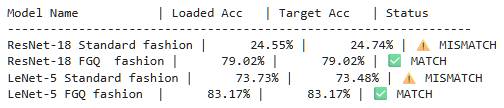

### Simpan ke pt


In [ ]:
# ==============================================
# LOAD & KONVERSI SAFETENSORS KE TORCHSCRIPT (.pt)
# ==============================================

import torch
import os
from safetensors.torch import load_file

# Path folder model
base_dir = '/content/drive/MyDrive/model_modular'
safetensors_dir = os.path.join(base_dir, 'safetensors_models')
export_dir = os.path.join(base_dir, 'torchscript_models')
os.makedirs(export_dir, exist_ok=True)

# ==============================================
# 1. DEFINISIKAN ULANG MODEL (sama seperti di notebook)
# ==============================================

class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = nn.functional.avg_pool2d(x, 2)
        x = torch.relu(self.conv2(x))
        x = nn.functional.avg_pool2d(x, 2)
        x = x.view(-1, 16 * 5 * 5)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNet18, self).__init__()
        from torchvision import models
        self.model = models.resnet18(weights=None)
        self.model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        num_ftrs = self.model.fc.in_features
        self.model.fc = nn.Linear(num_ftrs, num_classes)

    def forward(self, x):
        return self.model(x)

# ==============================================
# 2. LOAD DARI SAFETENSORS DAN KONVERSI KE .pt
# ==============================================

def convert_safetensors_to_pt(safetensors_path, model_class, export_name, device='cpu'):
    """
    Load model dari .safetensors dan ekspor ke .pt (TorchScript)
    """
    print(f"\n📦 Converting: {export_name}")

    # Buat model template
    template_model = model_class().to(device)

    # Load dari safetensors
    print(f"   Loading from: {safetensors_path}")
    model = load_ternary_safetensors(safetensors_path, template_model)
    model.to(device)
    model.eval()

    # Trace dengan contoh input
    example_input = torch.randn(1, 1, 28, 28).to(device)
    traced_model = torch.jit.trace(model, example_input)

    # Simpan ke .pt
    export_path = os.path.join(export_dir, f"{export_name}.pt")
    # traced_model.save(export_path)
    torch.jit.save(traced_model, export_path, _extra_files=None)
    print(f"✅ Saved to: {export_path}")

    return traced_model

# ==============================================
# 3. EKSEKUSI KONVERSI
# ==============================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 Device: {device}")

# Daftar model yang akan dikonversi
models_to_convert = [
    # (nama_file_safetensors, model_class, nama_export)
    ('lenet5_standard_fashion.safetensors', LeNet5, 'lenet5_standard_fashion'),
    ('lenet5_fgq_fashion.safetensors', LeNet5, 'lenet5_fgq_fashion'),
    ('resnet18_standard_fashion.safetensors', ResNet18, 'resnet18_standard_fashion'),
    ('resnet18_fgq_fashion.safetensors', ResNet18, 'resnet18_fgq_fashion'),
]

print("="*60)
print("🚀 CONVERTING SAFETENSORS TO TORCHSCRIPT")
print("="*60)

for safetensors_file, model_class, export_name in models_to_convert:
    safetensors_path = os.path.join(safetensors_dir, safetensors_file)

    if not os.path.exists(safetensors_path):
        print(f"⚠️ File not found: {safetensors_path}")
        continue

    try:
        convert_safetensors_to_pt(safetensors_path, model_class, export_name, device)
    except Exception as e:
        print(f"❌ Error converting {export_name}: {e}")

print("\n" + "="*60)
print("✅ ALL CONVERSIONS COMPLETE!")
print(f"📁 Output: {export_dir}")

In [ ]:
# Ekspor ulang semua model dengan torch.jit.save
import torch
import os

export_dir = '/content/drive/MyDrive/model_modular/torchscript_models'
os.makedirs(export_dir, exist_ok=True)

models_to_export = [
    (model_ternary_lenet, 'lenet5_standard_fashion'),
    # (best_model_fgq_lenet, 'lenet5_fgq_fashion'),
    (model_ternary_resnet, 'resnet18_standard_fashion'),
    # (best_model_fgq_resnet, 'resnet18_fgq_fashion'),
]

for model, name in models_to_export:
    model.eval()
    example_input = torch.randn(1, 1, 28, 28).to(device)

    # Gunakan torch.jit.script (lebih robust dari trace)
    scripted_model = torch.jit.script(model)

    # Simpan
    path = os.path.join(export_dir, f"{name}.pt")
    torch.jit.save(scripted_model, path)
    print(f"✅ Exported: {path}")

# **INFERENSI**

---



#### ResNet-18 Standard

In [ ]:
import torch
import time
import numpy as np
from PIL import Image
from google.colab import files
import os

# ==========================================
# 1. KONFIGURASI FASHION-MNIST
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 Menggunakan device: {device}")

# Parameter normalisasi standar Fashion-MNIST
FMNIST_MEAN = 0.2860
FMNIST_STD = 0.3530

# Mapping label Fashion-MNIST ke nama kelas
FASHION_LABELS = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

base_dir = '/content/drive/MyDrive/model_modular'
baseline_path = os.path.join(base_dir, 'resnet18_fashion_baseline_.pth')
quantized_path = os.path.join(base_dir, 'safetensors_models', 'resnet18_standard_fashion.safetensors')

# ==========================================
# 2. LOAD MODEL BASELINE (FP32) - FASHION
# ==========================================
print("\n📦 Memuat model Baseline Fashion-MNIST (FP32)...")
model_baseline = ResNet18().to(device)
checkpoint = torch.load(baseline_path, map_location=device)
model_baseline.load_state_dict(checkpoint['model_state_dict'])
model_baseline.eval()
print("✅ Baseline siap.")

# ==========================================
# 3. LOAD MODEL KUANTISASI (FASHION)
# ==========================================
print("\n📦 Memuat model Kuantisasi Fashion-MNIST (Standard Ternary)...")
model_quant = load_ternary_safetensors(quantized_path, ResNet18()).to(device)
model_quant.eval()
print("✅ Model kuantisasi siap.")

# ==========================================
# 4. FUNGSI BENCHMARK KECEPATAN
# ==========================================
def benchmark_speed(model, input_tensor, num_runs=100, warmup_runs=20):
    """Mengukur kecepatan inferensi rata-rata (ms dan FPS)."""
    # Warmup
    for _ in range(warmup_runs):
        with torch.no_grad():
            _ = model(input_tensor)

    if device.type == 'cuda':
        torch.cuda.synchronize()

    start_time = time.time()
    for _ in range(num_runs):
        with torch.no_grad():
            _ = model(input_tensor)

    if device.type == 'cuda':
        torch.cuda.synchronize()
    end_time = time.time()

    total_time_s = end_time - start_time
    avg_time_ms = (total_time_s / num_runs) * 1000
    fps = 1000 / avg_time_ms
    return avg_time_ms, fps

🔥 Menggunakan device: cpu

📦 Memuat model Baseline Fashion-MNIST (FP32)...
✅ Baseline siap.

📦 Memuat model Kuantisasi Fashion-MNIST (Standard Ternary)...
✅ Model kuantisasi siap.


In [ ]:
# ==========================================
# 1. UPLOAD GAMBAR CUSTOM
# ==========================================
print("📤 Silakan upload gambar fashion (sepatu, baju, tas, dll) format JPG/PNG:")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
print(f"✅ Berhasil upload: {image_path}")

# ==========================================
# 2. FUNGSI PREPROSES (FASHION-MNIST STANDARD)
# ==========================================
def preprocess_fashion_image(path, mean=FMNIST_MEAN, std=FMNIST_STD):
    img = Image.open(path).convert('L')
    img = img.resize((28, 28), Image.Resampling.LANCZOS)
    img_array = np.array(img, dtype=np.float32) / 255.0
    img_tensor = (img_array - mean) / std
    img_tensor = torch.from_numpy(img_tensor).unsqueeze(0).unsqueeze(0)
    return img_tensor.to(device)

input_tensor = preprocess_fashion_image(image_path)
print(f"✅ Shape input tensor: {input_tensor.shape}")

# ==========================================
# 3. EKSEKUSI BENCHMARK & PREDIKSI
# ==========================================
print("\n" + "="*60)
print("🚀 Benchmarking Kecepatan Inferensi - Fashion-MNIST")
print("="*60)

print("\n🔹 Baseline (FP32):")
avg_t, fps = benchmark_speed(model_baseline, input_tensor)
with torch.no_grad():
    pred_idx = model_baseline(input_tensor).argmax().item()
    pred_label = FASHION_LABELS[pred_idx]
print(f"   ⏱️  Rata-rata waktu: {avg_t:.4f} ms")
print(f"   📈 FPS: {fps:.2f} gambar/detik")
print(f"   🎯 Prediksi: {pred_label} (index {pred_idx})")

print("\n🔹 Kuantisasi Standard Ternary:")
avg_t_q, fps_q = benchmark_speed(model_quant, input_tensor)
with torch.no_grad():
    pred_idx_q = model_quant(input_tensor).argmax().item()
    pred_label_q = FASHION_LABELS[pred_idx_q]
print(f"   ⏱️  Rata-rata waktu: {avg_t_q:.4f} ms")
print(f"   📈 FPS: {fps_q:.2f} gambar/detik")
print(f"   🎯 Prediksi: {pred_label_q} (index {pred_idx_q})")

# ==========================================
# 4. PERBANDINGAN SPEEDUP & VERIFIKASI
# ==========================================
speedup = avg_t / avg_t_q
print("\n" + "="*60)
print("📊 RINGKASAN PERBANDINGAN")
print("="*60)
print(f"⚡ Speedup (Baseline vs Kuantisasi): {speedup:.2f}x lebih cepat")
print(f"✅ Hasil prediksi sama? {'Ya ✅' if pred_idx == pred_idx_q else 'Tidak ❌'}")

try:
    from IPython.display import display
    print("\n🖼️ Gambar yang diupload:")
    display(Image.open(image_path))
except:
    pass

📤 Silakan upload gambar fashion (sepatu, baju, tas, dll) format JPG/PNG:


Saving 0.png to 0 (1).png
✅ Berhasil upload: 0 (1).png
✅ Shape input tensor: torch.Size([1, 1, 28, 28])

🚀 Benchmarking Kecepatan Inferensi - Fashion-MNIST

🔹 Baseline (FP32):
   ⏱️  Rata-rata waktu: 8.9556 ms
   📈 FPS: 111.66 gambar/detik
   🎯 Prediksi: Ankle boot (index 9)

🔹 Kuantisasi Standard Ternary:
   ⏱️  Rata-rata waktu: 10.5107 ms
   📈 FPS: 95.14 gambar/detik
   🎯 Prediksi: Bag (index 8)

📊 RINGKASAN PERBANDINGAN
⚡ Speedup (Baseline vs Kuantisasi): 0.85x lebih cepat
✅ Hasil prediksi sama? Tidak ❌

🖼️ Gambar yang diupload:


#### ResNet-18 Fine-Grained

In [ ]:
import torch
import time
import numpy as np
from PIL import Image
from google.colab import files
import os

# ==========================================
# 1. KONFIGURASI FASHION-MNIST
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 Menggunakan device: {device}")

# Parameter normalisasi standar Fashion-MNIST
FMNIST_MEAN = 0.2860
FMNIST_STD = 0.3530

# Mapping label Fashion-MNIST ke nama kelas
FASHION_LABELS = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

base_dir = '/content/drive/MyDrive/model_modular'
baseline_path_fgq = os.path.join(base_dir, 'resnet18_fashion_baseline.pth')
quantized_path_fgq = os.path.join(base_dir, 'safetensors_models', 'resnet18_fgq_fashion.safetensors')

# ==========================================
# 2. LOAD MODEL BASELINE (FP32) - FASHION
# ==========================================
print("\n📦 Memuat model Baseline Fashion-MNIST (FP32)...")
model_baseline = ResNet18().to(device)
checkpoint = torch.load(baseline_path, map_location=device)
model_baseline.load_state_dict(checkpoint['model_state_dict'])
model_baseline.eval()
print("✅ Baseline siap.")

# ==========================================
# 3. LOAD MODEL KUANTISASI (FASHION)
# ==========================================
print("\n📦 Memuat model Kuantisasi Fashion-MNIST (Fine-Grained Ternary)...")
model_quant_fgq = load_ternary_safetensors(quantized_path, ResNet18()).to(device)
model_quant_fgq.eval()
print("✅ Model kuantisasi siap.")

# ==========================================
# 4. FUNGSI BENCHMARK KECEPATAN
# ==========================================
def benchmark_speed(model, input_tensor, num_runs=100, warmup_runs=20):
    """Mengukur kecepatan inferensi rata-rata (ms dan FPS)."""
    # Warmup
    for _ in range(warmup_runs):
        with torch.no_grad():
            _ = model(input_tensor)

    if device.type == 'cuda':
        torch.cuda.synchronize()

    start_time = time.time()
    for _ in range(num_runs):
        with torch.no_grad():
            _ = model(input_tensor)

    if device.type == 'cuda':
        torch.cuda.synchronize()
    end_time = time.time()

    total_time_s = end_time - start_time
    avg_time_ms = (total_time_s / num_runs) * 1000
    fps = 1000 / avg_time_ms
    return avg_time_ms, fps

In [ ]:
# ==========================================
# 1. UPLOAD GAMBAR CUSTOM
# ==========================================
print("📤 Silakan upload gambar fashion (sepatu, baju, tas, dll) format JPG/PNG:")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
print(f"✅ Berhasil upload: {image_path}")

# ==========================================
# 2. FUNGSI PREPROSES (FASHION-MNIST STANDARD)
# ==========================================
def preprocess_fashion_image(path, mean=FMNIST_MEAN, std=FMNIST_STD):
    img = Image.open(path).convert('L')
    img = img.resize((28, 28), Image.Resampling.LANCZOS)
    img_array = np.array(img, dtype=np.float32) / 255.0
    img_tensor = (img_array - mean) / std
    img_tensor = torch.from_numpy(img_tensor).unsqueeze(0).unsqueeze(0)
    return img_tensor.to(device)

input_tensor = preprocess_fashion_image(image_path)
print(f"✅ Shape input tensor: {input_tensor.shape}")

# ==========================================
# 3. EKSEKUSI BENCHMARK & PREDIKSI
# ==========================================
print("\n" + "="*60)
print("🚀 Benchmarking Kecepatan Inferensi - Fashion-MNIST")
print("="*60)

print("\n🔹 Baseline (FP32):")
avg_t, fps = benchmark_speed(model_baseline, input_tensor)
with torch.no_grad():
    pred_idx = model_baseline(input_tensor).argmax().item()
    pred_label = FASHION_LABELS[pred_idx]
print(f"   ⏱️  Rata-rata waktu: {avg_t:.4f} ms")
print(f"   📈 FPS: {fps:.2f} gambar/detik")
print(f"   🎯 Prediksi: {pred_label} (index {pred_idx})")

print("\n🔹 Kuantisasi Fine-Grained Ternary:")
avg_t_q, fps_q = benchmark_speed(model_quant_fgq, input_tensor)
with torch.no_grad():
    pred_idx_q = model_quant_fgq(input_tensor).argmax().item()
    pred_label_q = FASHION_LABELS[pred_idx_q]
print(f"   ⏱️  Rata-rata waktu: {avg_t_q:.4f} ms")
print(f"   📈 FPS: {fps_q:.2f} gambar/detik")
print(f"   🎯 Prediksi: {pred_label_q} (index {pred_idx_q})")

# ==========================================
# 4. PERBANDINGAN SPEEDUP & VERIFIKASI
# ==========================================
speedup = avg_t / avg_t_q
print("\n" + "="*60)
print("📊 RINGKASAN PERBANDINGAN")
print("="*60)
print(f"⚡ Speedup (Baseline vs Kuantisasi): {speedup:.2f}x lebih cepat")
print(f"✅ Hasil prediksi sama? {'Ya ✅' if pred_idx == pred_idx_q else 'Tidak ❌'}")

try:
    from IPython.display import display
    print("\n🖼️ Gambar yang diupload:")
    display(Image.open(image_path))
except:
    pass

#### LeNet-5 Standard

In [ ]:
import torch
import time
import numpy as np
from PIL import Image
from google.colab import files
import os

# ==========================================
# 1. KONFIGURASI FASHION-MNIST
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 Menggunakan device: {device}")

# Parameter normalisasi standar Fashion-MNIST
# FMNIST_MEAN = 0.2860
# FMNIST_STD = 0.3530
FMNIST_MEAN = 0.5
FMNIST_STD = 0.5

# Mapping label Fashion-MNIST ke nama kelas
FASHION_LABELS = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

base_dir = '/content/drive/MyDrive/model_modular'
baseline_path = os.path.join(base_dir, 'lenet5_fashion_baseline_v2.pth')
quantized_path = os.path.join(base_dir, 'safetensors_models', 'lenet5_standard_fashion_v2_symmetric.safetensors')

# ==========================================
# 2. LOAD MODEL BASELINE (FP32) - FASHION
# ==========================================
print("\n📦 Memuat model Baseline Fashion-MNIST (FP32)...")
model_baseline = LeNet5().to(device)
checkpoint = torch.load(baseline_path, map_location=device)
model_baseline.load_state_dict(checkpoint['model_state_dict'])
model_baseline.eval()
print("✅ Baseline siap.")

# ==========================================
# 3. LOAD MODEL KUANTISASI (FASHION)
# ==========================================
print("\n📦 Memuat model Kuantisasi Fashion-MNIST (Standard Ternary)...")
model_quant = load_ternary_safetensors(quantized_path, LeNet5()).to(device)
model_quant.eval()
print("✅ Model kuantisasi siap.")

# ==========================================
# 4. FUNGSI BENCHMARK KECEPATAN
# ==========================================
def benchmark_speed(model, input_tensor, num_runs=100, warmup_runs=20):
    """Mengukur kecepatan inferensi rata-rata (ms dan FPS)."""
    # Warmup
    for _ in range(warmup_runs):
        with torch.no_grad():
            _ = model(input_tensor)

    if device.type == 'cuda':
        torch.cuda.synchronize()

    start_time = time.time()
    for _ in range(num_runs):
        with torch.no_grad():
            _ = model(input_tensor)

    if device.type == 'cuda':
        torch.cuda.synchronize()
    end_time = time.time()

    total_time_s = end_time - start_time
    avg_time_ms = (total_time_s / num_runs) * 1000
    fps = 1000 / avg_time_ms
    return avg_time_ms, fps

🔥 Menggunakan device: cpu

📦 Memuat model Baseline Fashion-MNIST (FP32)...
✅ Baseline siap.

📦 Memuat model Kuantisasi Fashion-MNIST (Standard Ternary)...

🔍 Debug Load (FIXED: per-group alpha):
✅ Berhasil parse JSON: 5 layers
  ⚠️ conv1: file lama (format single-alpha), akurasi mungkin masih mismatch
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.423968
        Orig mean: -0.002453, Rec mean: 0.038879
  ⚠️ conv2: file lama (format single-alpha), akurasi mungkin masih mismatch
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.189029
        Orig mean: -0.000451, Rec mean: 0.000672
  ⚠️ fc1: file lama (format single-alpha), akurasi mungkin masih mismatch
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.122202
        Orig mean: 0.000274, Rec mean: -0.003510
  ⚠️ fc2: file lama (format single-alpha), akurasi mungkin masih mismatch
     ⚠️ PERBEDAAN DETEKSI! max_diff=0.175415
        Orig mean: -0.000331, Rec mean: -0.000401
  ⚠️ fc3: file lama (format single-alpha), akurasi mungkin masih mismatch
     ⚠️ PERBEDAAN DETE

In [ ]:
# ==========================================
# 1. UPLOAD GAMBAR CUSTOM
# ==========================================
print("📤 Silakan upload gambar fashion (sepatu, baju, tas, dll) format JPG/PNG:")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
print(f"✅ Berhasil upload: {image_path}")

# ==========================================
# 2. FUNGSI PREPROSES (FASHION-MNIST STANDARD)
# ==========================================
def preprocess_fashion_image(path, mean=FMNIST_MEAN, std=FMNIST_STD):
    img = Image.open(path).convert('L')
    img = img.resize((28, 28), Image.Resampling.LANCZOS)
    img_array = np.array(img, dtype=np.float32) / 255.0
    img_tensor = (img_array - mean) / std
    img_tensor = torch.from_numpy(img_tensor).unsqueeze(0).unsqueeze(0)
    return img_tensor.to(device)

input_tensor = preprocess_fashion_image(image_path)
print(f"✅ Shape input tensor: {input_tensor.shape}")


# ==========================================
# 3. EKSEKUSI BENCHMARK & PREDIKSI
# ==========================================
print("\n" + "="*60)
print("🚀 Benchmarking Kecepatan Inferensi - Fashion-MNIST")
print("="*60)

print("\n🔹 Baseline (FP32):")
avg_t, fps = benchmark_speed(model_baseline, input_tensor)
with torch.no_grad():
    pred_idx = model_baseline(input_tensor).argmax().item()
    pred_label = FASHION_LABELS[pred_idx]
print(f"   ⏱️  Rata-rata waktu: {avg_t:.4f} ms")
print(f"   📈 FPS: {fps:.2f} gambar/detik")
print(f"   🎯 Prediksi: {pred_label} (index {pred_idx})")

print("\n🔹 Kuantisasi Standard Ternary:")
avg_t_q, fps_q = benchmark_speed(model_quant, input_tensor)
with torch.no_grad():
    pred_idx_q = model_quant(input_tensor).argmax().item()
    pred_label_q = FASHION_LABELS[pred_idx_q]
print(f"   ⏱️  Rata-rata waktu: {avg_t_q:.4f} ms")
print(f"   📈 FPS: {fps_q:.2f} gambar/detik")
print(f"   🎯 Prediksi: {pred_label_q} (index {pred_idx_q})")

# ==========================================
# 4. PERBANDINGAN SPEEDUP & VERIFIKASI
# ==========================================
speedup = avg_t / avg_t_q
print("\n" + "="*60)
print("📊 RINGKASAN PERBANDINGAN")
print("="*60)
print(f"⚡ Speedup (Baseline vs Kuantisasi): {speedup:.2f}x lebih cepat")
print(f"✅ Hasil prediksi sama? {'Ya ✅' if pred_idx == pred_idx_q else 'Tidak ❌'}")

try:
    from IPython.display import display
    print("\n🖼️ Gambar yang diupload:")
    display(Image.open(image_path))
except:
    pass

📤 Silakan upload gambar fashion (sepatu, baju, tas, dll) format JPG/PNG:


Saving 0.png to 0.png
✅ Berhasil upload: 0.png
✅ Shape input tensor: torch.Size([1, 1, 28, 28])

🚀 Benchmarking Kecepatan Inferensi - Fashion-MNIST

🔹 Baseline (FP32):
   ⏱️  Rata-rata waktu: 0.3879 ms
   📈 FPS: 2577.83 gambar/detik
   🎯 Prediksi: Ankle boot (index 9)

🔹 Kuantisasi Standard Ternary:
   ⏱️  Rata-rata waktu: 0.4054 ms
   📈 FPS: 2466.98 gambar/detik
   🎯 Prediksi: Ankle boot (index 9)

📊 RINGKASAN PERBANDINGAN
⚡ Speedup (Baseline vs Kuantisasi): 0.96x lebih cepat
✅ Hasil prediksi sama? Ya ✅

🖼️ Gambar yang diupload:


#### LeNet-5 Fine-Grained

In [ ]:
import torch
import time
import numpy as np
from PIL import Image
from google.colab import files
import os

# ==========================================
# 1. KONFIGURASI FASHION-MNIST
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 Menggunakan device: {device}")

# Parameter normalisasi standar Fashion-MNIST
FMNIST_MEAN = 0.2860
FMNIST_STD = 0.3530

# Mapping label Fashion-MNIST ke nama kelas
FASHION_LABELS = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

base_dir = '/content/drive/MyDrive/model_modular'
baseline_path = os.path.join(base_dir, 'lenet5_fashion_baseline.pth')
quantized_path_fgq = os.path.join(base_dir, 'safetensors_models', 'lenet5_fgq_fashion.safetensors')

# ==========================================
# 2. LOAD MODEL BASELINE (FP32) - FASHION
# ==========================================
print("\n📦 Memuat model Baseline Fashion-MNIST (FP32)...")
model_baseline = LeNet5().to(device)  # arsitektur sama
checkpoint = torch.load(baseline_path, map_location=device)
model_baseline.load_state_dict(checkpoint['model_state_dict'])
model_baseline.eval()
print("✅ Baseline siap.")

# ==========================================
# 3. LOAD MODEL KUANTISASI (FASHION)
# ==========================================
print("\n📦 Memuat model Kuantisasi Fashion-MNIST (Fine-Grained Ternary)...")
model_quant_fgq = load_ternary_safetensors(quantized_path_fgq, LeNet5()).to(device)
model_quant_fgq.eval()
print("✅ Model kuantisasi siap.")

# ==========================================
# 4. FUNGSI BENCHMARK KECEPATAN
# ==========================================
def benchmark_speed(model, input_tensor, num_runs=100, warmup_runs=20):
    """Mengukur kecepatan inferensi rata-rata (ms dan FPS)."""
    # Warmup
    for _ in range(warmup_runs):
        with torch.no_grad():
            _ = model(input_tensor)

    if device.type == 'cuda':
        torch.cuda.synchronize()

    start_time = time.time()
    for _ in range(num_runs):
        with torch.no_grad():
            _ = model(input_tensor)

    if device.type == 'cuda':
        torch.cuda.synchronize()
    end_time = time.time()

    total_time_s = end_time - start_time
    avg_time_ms = (total_time_s / num_runs) * 1000
    fps = 1000 / avg_time_ms
    return avg_time_ms, fps

In [ ]:
# ==========================================
# 1. UPLOAD GAMBAR CUSTOM
# ==========================================
print("📤 Silakan upload gambar fashion (sepatu, baju, tas, dll) format JPG/PNG:")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
print(f"✅ Berhasil upload: {image_path}")

# ==========================================
# 2. FUNGSI PREPROSES (FASHION-MNIST FINE-GRAINED)
# ==========================================
def preprocess_fashion_image(path, mean=FMNIST_MEAN, std=FMNIST_STD):
    img = Image.open(path).convert('L')
    img = img.resize((28, 28), Image.Resampling.LANCZOS)
    img_array = np.array(img, dtype=np.float32) / 255.0
    img_tensor = (img_array - mean) / std
    img_tensor = torch.from_numpy(img_tensor).unsqueeze(0).unsqueeze(0)
    return img_tensor.to(device)

input_tensor = preprocess_fashion_image(image_path)
print(f"✅ Shape input tensor: {input_tensor.shape}")


# ==========================================
# 3. EKSEKUSI BENCHMARK & PREDIKSI
# ==========================================
print("\n" + "="*60)
print("🚀 Benchmarking Kecepatan Inferensi - Fashion-MNIST")
print("="*60)

print("\n🔹 Baseline (FP32):")
avg_t, fps = benchmark_speed(model_baseline, input_tensor)
with torch.no_grad():
    pred_idx = model_baseline(input_tensor).argmax().item()
    pred_label = FASHION_LABELS[pred_idx]
print(f"   ⏱️  Rata-rata waktu: {avg_t:.4f} ms")
print(f"   📈 FPS: {fps:.2f} gambar/detik")
print(f"   🎯 Prediksi: {pred_label} (index {pred_idx})")

print("\n🔹 Kuantisasi Fine-Grained Ternary:")
avg_t_q, fps_q = benchmark_speed(model_quant_fgq, input_tensor)
with torch.no_grad():
    pred_idx_q = model_quant_fgq(input_tensor).argmax().item()
    pred_label_q = FASHION_LABELS[pred_idx_q]
print(f"   ⏱️  Rata-rata waktu: {avg_t_q:.4f} ms")
print(f"   📈 FPS: {fps_q:.2f} gambar/detik")
print(f"   🎯 Prediksi: {pred_label_q} (index {pred_idx_q})")

# ==========================================
# 4. PERBANDINGAN SPEEDUP & VERIFIKASI
# ==========================================
speedup = avg_t / avg_t_qinsins
print("\n" + "="*60)
print("📊 RINGKASAN PERBANDINGAN")
print("="*60)
print(f"⚡ Speedup (Baseline vs Kuantisasi): {speedup:.2f}x lebih cepat")
print(f"✅ Hasil prediksi sama? {'Ya ✅' if pred_idx == pred_idx_q else 'Tidak ❌'}")

try:
    from IPython.display import display
    print("\n🖼️ Gambar yang diupload:")
    display(Image.open(image_path))
except:
    pass

# INFERENSI DENGAN CPP

## Setup Library dan File

In [ ]:
%%shell
# Hapus LibTorch lama jika ada
rm -rf /content/libtorch
rm -f libtorch-cxx11-abi-shared-with-deps-2.4.0+cpu.zip

# Download LibTorch versi 2.4.0
wget -q https://download.pytorch.org/libtorch/cpu/libtorch-cxx11-abi-shared-with-deps-2.4.0%2Bcpu.zip

# Ekstraksi ke /content/
unzip -q libtorch-cxx11-abi-shared-with-deps-2.4.0+cpu.zip -d /content/

# Cari lokasi file config secara dinamis untuk verifikasi
find /content/libtorch -name "TorchConfigVersion.cmake" -exec cat {} \; | grep VERSION

set(PACKAGE_VERSION "2.4.0")
# Check whether the requested PACKAGE_FIND_VERSION is compatible
if("${PACKAGE_VERSION}" VERSION_LESS "${PACKAGE_FIND_VERSION}")
  set(PACKAGE_VERSION_COMPATIBLE FALSE)
  set(PACKAGE_VERSION_COMPATIBLE TRUE)
  if("${PACKAGE_VERSION}" VERSION_EQUAL "${PACKAGE_FIND_VERSION}")
    set(PACKAGE_VERSION_EXACT TRUE)


In [ ]:
from google.colab import drive
import os

# 1. Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# 2. Definisikan path sumber (Drive) dan tujuan (/content)
source_path = '/content/drive/MyDrive/Project/Projek_Skripsi/*'
destination_path = '/content/'

# 3. Salin semua folder dan file ke /content
!cp -r {source_path} {destination_path}

print("✅ Semua folder dari 'Project/Projek Skripsi' telah berhasil disalin ke /content")

Mounted at /content/drive
✅ Semua folder dari 'Project/Projek Skripsi' telah berhasil disalin ke /content


## Build File Inferensi

In [ ]:
import os
os.chdir('/content/cpp_inference')
# Build menggunakan LibTorch yang baru diinstal
!cmake -B build -DCMAKE_PREFIX_PATH=/content/libtorch -DCMAKE_BUILD_TYPE=Release
!cmake --build build -j4

-- The C compiler identification is GNU 13.3.0
-- The CXX compiler identification is GNU 13.3.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /usr/bin/c++ - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Found Torch: /content/libtorch/lib/libtorch.so
-- Configuring done (1.3s)
-- Generating done (0.0s)
-- Build files have been written to: /content/cpp_inference/build
[ 50%] Building CXX object CMakeFiles/inference.dir/main.cpp.o
[100%] Linking CXX executable inference
[100%] Built target inference


## Inferensi

In [ ]:
import os
os.environ['LD_LIBRARY_PATH'] = '/content/libtorch/lib'
!./build/inference lenet5_fashion_baseline 20 10 /content auto
!./build/inference lenet5_standard_fashion_v2_symmetric 20 10 /content ssr
# !./build/inference lenet5_fgq_fashion 20 10 /content auto

LIBTORCH INFERENCE : FP32 / TERNARY / SSR MATMUL
Model : lenet5_fashion_baseline
  file : /content/torchscript_models/lenet5_fashion_baseline.pt
  input: /content/data/batch_input.bin

Loading torchscript model...
OK: model loaded

Reading input...
   Loaded 100 samples from /content/data/batch_input.bin

Layer decomposition:
   conv1 (conv 6x1x5x5) [non-ternary] alpha=(per grup/non)
   conv2 (conv 16x6x5x5) [non-ternary] alpha=(per grup/non)
   fc1 (fc   120x400) [non-ternary] alpha=(per grup/non)
   fc2 (fc   84x120) [non-ternary] alpha=(per grup/non)
   fc3 (fc   10x84) [non-ternary] alpha=(per grup/non)

BENCHMARK FP32 MATMUL : lenet5_fashion_baseline
   [warmup 10 runs]...
   [benchmark 20 runs]...

RESULTS
   MODE fp32 : avg=73.631 ms  std=26.5561  min=33.3489  max=128.008  fps=13.5812
   Model kind : pt

Verification (sample 1):
   FP32 -> class 9 (Ankle boot)
   [saved] /content/output/lenet5_fashion_baseline_cpp_results.json

Done!
LIBTORCH INFERENCE : FP32 / TERNARY / SSR MAT

In [ ]:
import os
os.environ['LD_LIBRARY_PATH'] = '/content/libtorch/lib'
!./build/inference resnet18_fashion_baseline 20 10 /content
!./build/inference resnet18_standard_fashion 20 10 /content ssr
!./build/inference resnet18_fgq_fashion 20 10 /content

LIBTORCH INFERENCE : FP32 / TERNARY / SSR MATMUL
Model : resnet18_fashion_baseline
  file : /content/torchscript_models/resnet18_fashion_baseline.pt
  input: /content/data/batch_input.bin

Loading torchscript model...
OK: model loaded

Reading input...
   Loaded 100 samples from /content/data/batch_input.bin

Layer decomposition:
   model.conv1 (conv 64x1x7x7) [non-ternary] alpha=(per grup/non) +BN
   model.fc (fc   10x512) [non-ternary] alpha=(per grup/non)
   model.layer1.0.conv1 (conv 64x64x3x3) [non-ternary] alpha=(per grup/non) +BN
   model.layer1.0.conv2 (conv 64x64x3x3) [non-ternary] alpha=(per grup/non) +BN
   model.layer1.1.conv1 (conv 64x64x3x3) [non-ternary] alpha=(per grup/non) +BN
   model.layer1.1.conv2 (conv 64x64x3x3) [non-ternary] alpha=(per grup/non) +BN
   model.layer2.0.conv1 (conv 128x64x3x3) [non-ternary] alpha=(per grup/non) +BN
   model.layer2.0.conv2 (conv 128x128x3x3) [non-ternary] alpha=(per grup/non) +BN
   model.layer2.0.downsample.0 (conv 128x64x1x1) [non-

In [ ]:
!./build/inference resnet18_standard_fashion 20 10 /content